In [1]:
from handwriting_sample import HandwritingSample as hs

svc_sample = hs.from_svc(path="C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc")
print(svc_sample)



2025-10-27 15:46:54 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:46:54 - 272 - SVCFileReader - Data has been loaded from an SVC file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
<HandwritingSampleObject: 
DATA:
   x =          [239.91  239.91  239.91  ... 267.82  267.8   267.645], 
   y =          [141.41  141.41  141.41  ... 134.06  134.155 134.465], 
   time =       [0.0000e+00 7.0000e-03 1.5000e-02 ... 1.7539e+01 1.7547e+01 1.7554e+01], 
   pen_status = [ True  True  True ...  True  True  True], 
   azimuth =    [1390. 1390. 1400. ... 1420. 1420. 1420.], 
   tilt =       [560. 560. 560. ... 590. 590. 590.], 
   pressure =   [0.002933 0.025415 0.047898 ... 0.260997 0.246334 0.057674]> 


METADATA:
dict_items([('samples_count', 2336)])


In [ ]:
from handwriting_features import HandwritingFeatures as hf

data_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc"

variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]

fs = 133  # Sampling frequency in Hz

feature_data = hf.from_svc(data_path, variables)

# 1. Kinematic features
x_velocity = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
y_velocity = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])

pressure = feature_data.pressure(statistics=["median", "std"])

print("X Velocity Features:", x_velocity)
print("Y Velocity Features:", y_velocity)
print("Pressure Features:", pressure)

DEBUG:fsspec.local:open file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
2025-10-27 15:46:57 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:46:57 - 272 - SVCFileReader - Data has been loaded from an SVC file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
X Velocity Features: [23.58355521 15.80903653]
Y Velocity Features: [26.17234362 20.51260332]
Pressure Features: [0.173021   0.03585308]


In [1]:
import os
from pathlib import Path
import pandas as pd
from handwriting_features import HandwritingFeatures as hf

directory_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002"

pathlist = Path(directory_path).rglob("*.svc")

variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]
pd_rows = []
fs = 133  # Sampling frequency in Hz
i = 0

def diagnosis_from_filename(filename):
    if filename.startswith("HC"):
        return 1
    elif filename.startswith("pre-LBD"):
        return 0
    else:
        return None  # or raise an exception if appropriate
for path in pathlist:
    feature_data = hf.from_svc(str(path), variables)
    diagnosis = diagnosis_from_filename(path.name)
    x_velocity_loop = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
    y_velocity_loop = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])
    pressure_loop = feature_data.pressure(statistics=["mean", "std"])
    
    pandas_row = {
        "file_name": path.name,
        "diagnosis": diagnosis,
        "x_velocity_mean" : x_velocity_loop[0],
        "x_velocity_std" : x_velocity_loop[1],
        "y_velocity_mean" : y_velocity_loop[0],
        "y_velocity_std" : y_velocity_loop[1],
        "pressure_mean" : pressure_loop[0],
        "pressure_std" : pressure_loop[1]
    }
    pd_rows.append(pandas_row)
    i = i + 1
df = pd.DataFrame(pd_rows)

print("Processed files:", i)

2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.10_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.15_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.16_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DO

In [53]:
# split df to 
## 1 - whole dataset - HC
df_hc = df[df["diagnosis"] == 0]
#df_hc.head()
## 2 - whole dataset - prelBD
df_preLBD = df[df["diagnosis"] == 1]
#df_preLBD.head()
## 3 - by handwriting task - HC

### w.cz.fnusa.1_1.svc
df_hc_task1_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
df_task1_1 = df[df["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
#df_hc_task1_1.head()
### w.cz.fnusa.3_1.svc
df_hc_task3_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
df_task3_1 = df[df["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
#df_hc_task3_1.head()
### w.cz.fnusa.3_2.svc
df_hc_task3_2 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
df_task3_2 = df[df["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
#df_hc_task3_2.head()
### w.cz.fnusa.3_3.svc
df_hc_task3_3 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
df_task3_3 = df[df["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
#df_hc_task3_3.head()
### w.cz.fnusa.3_3.svc
df_hc_task3_4 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
df_task3_4 = df[df["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
#df_hc_task3_4.head()
### w.cz.fnusa.3_5.svc
df_hc_task3_5 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
df_task3_5 = df[df["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
#df_hc_task3_5.head()
### w.cz.fnusa.9_1.svc
df_hc_task9_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
df_task9_1 = df[df["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
#df_hc_task9_1.head()
### w.cz.fnusa.10_1.svc
df_hc_task10_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
df_task10_1 = df[df["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
#df_hc_task10_1.head()
### w.cz.fnusa.15_1.svc
df_hc_task15_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
df_task15_1 = df[df["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
#df_hc_task15_1.head()
### w.cz.fnusa.16_1.svc
df_hc_task16_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
df_task16_1 = df[df["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
#df_hc_task16_1.head()
### w.cz.fnusa.17_1.svc
df_hc_task17_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
df_task17_1 = df[df["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
#df_hc_task17_1.head()
### w.cz.fnusa.18_1.svc
df_hc_task18_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
df_task18_1 = df[df["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
#df_hc_task18_1.head()
### w.cz.fnusa.19_1.svc
df_hc_task19_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
df_task19_1 = df[df["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
#df_hc_task19_1.head()
## 4 - by handwriting task - prelBD

### w.cz.fnusa.1_1.svc
df_preLBD_task1_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
df_task1_1 = df[df["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
#df_preLBD_task1_1.head()
### w.cz.fnusa.3_1.svc
df_preLBD_task3_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
df_task3_1 = df[df["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
#df_preLBD_task3_1.head()
### w.cz.fnusa.3_2.svc
df_preLBD_task3_2 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
df_task3_2 = df[df["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
#df_preLBD_task3_2.head()
### w.cz.fnusa.3_3.svc
df_preLBD_task3_3 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
df_task3_3 = df[df["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
#df_preLBD_task3_3.head()
### w.cz.fnusa.3_3.svc
df_preLBD_task3_4 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
df_task3_4 = df[df["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
#df_preLBD_task3_4.head()
### w.cz.fnusa.3_5.svc
df_preLBD_task3_5 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
df_task3_5 = df[df["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
#df_preLBD_task3_5.head()
### w.cz.fnusa.9_1.svc
df_preLBD_task9_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
df_task9_1 = df[df["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
#df_preLBD_task9_1.head()
### w.cz.fnusa.10_1.svc
df_preLBD_task10_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
df_task10_1 = df[df["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
#df_preLBD_task10_1.head()
### w.cz.fnusa.15_1.svc
df_preLBD_task15_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
df_task15_1 = df[df["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
#df_preLBD_task15_1.head()
### w.cz.fnusa.16_1.svc
df_preLBD_task16_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
df_task16_1 = df[df["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
#df_preLBD_task16_1.head()
### w.cz.fnusa.17_1.svc
df_preLBD_task17_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
df_task17_1 = df[df["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
#df_preLBD_task17_1.head()
### w.cz.fnusa.18_1.svc
df_preLBD_task18_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
df_task18_1 = df[df["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
#df_preLBD_task18_1.head()
### w.cz.fnusa.19_1.svc
df_preLBD_task19_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
df_task19_1 = df[df["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
df_task19_1.sample(20)

,file_name,diagnosis,x_velocity_mean,x_velocity_std,y_velocity_mean,y_velocity_std,pressure_mean,pressure_std
1775,pre-LBD-9#1_w.cz.fnusa.19_1.svc,0,21.706840,25.165990,18.067406,18.028721,0.602324,0.132196
1517,pre-LBD-70#1_w.cz.fnusa.19_1.svc,0,25.191759,26.784955,19.992368,21.564822,0.309736,0.078977
1244,pre-LBD-50#1_w.cz.fnusa.19_1.svc,0,31.186527,24.264058,22.218426,19.092675,0.449443,0.094584
234,HC-25#1_w.cz.fnusa.19_1.svc,1,18.918507,18.603696,20.977022,19.161797,0.478553,0.117907
999,pre-LBD-32#1_w.cz.fnusa.19_1.svc,0,23.152830,20.740848,23.026710,20.203214,0.190184,0.084674
364,HC-34#1_w.cz.fnusa.19_1.svc,1,22.840348,19.134983,15.807215,13.842384,0.317520,0.079667
208,HC-23#1_w.cz.fnusa.19_1.svc,1,34.616377,33.018788,18.575910,17.010903,0.301221,0.074150
455,pre-LBD-10#1_w.cz.fnusa.19_1.svc,0,24.992708,23.348968,25.106597,22.173223,0.350662,0.106762
1270,pre-LBD-52#1_w.cz.fnusa.19_1.svc,0,21.676152,19.917188,30.821488,23.960866,0.525974,0.123726
260,HC-27#1_w.cz.fnusa.19_1.svc,1,21.987275,22.167051,21.346410,20.685376,0.365058,0.097508


In [24]:
# Mann-Whitney U test whole database
from scipy.stats import mannwhitneyu

# Whole datbase
## X - axis velocity mean
hc_xvel_mean = df_hc["x_velocity_mean"]
preLBD_xvel_mean = df_preLBD["x_velocity_mean"]

stat_xvel_mean, p_xvel_mean = mannwhitneyu(hc_xvel_mean, preLBD_xvel_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean}, p-value={p_xvel_mean}")
## X - axis velocity std

hc_xvel_std = df_hc["x_velocity_std"]
preLBD_xvel_std = df_preLBD["x_velocity_std"]

stat_xvel_std, p_xvel_std = mannwhitneyu(hc_xvel_std, preLBD_xvel_std, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std}, p-value={p_xvel_std}")
## Y - axis velocity mean
hc_yvel_mean = df_hc["y_velocity_mean"]
preLBD_yvel_mean = df_preLBD["y_velocity_mean"]

stat_yvel_mean, p_yvel_mean = mannwhitneyu(hc_yvel_mean, preLBD_yvel_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean}, p-value={p_yvel_mean}")
## Y - axis velocity std
hc_yvel_std = df_hc["y_velocity_std"]
preLBD_yvel_std = df_preLBD["y_velocity_std"]

stat_yvel_std, p_yvel_std = mannwhitneyu(hc_yvel_std, preLBD_yvel_std, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std}, p-value={p_yvel_std}")
## Pressure mean
hc_pressure_mean = df_hc["pressure_mean"]
preLBD_pressure_mean = df_preLBD["pressure_mean"]

stat_pressure_mean, p_pressure_mean = mannwhitneyu(hc_pressure_mean, preLBD_pressure_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean}, p-value={p_pressure_mean}")
## Pressure std
hc_pressure_std = df_hc["y_velocity_std"]
preLBD_pressure_std = df_preLBD["y_velocity_std"]

stat_pressure_std, p_pressure_std = mannwhitneyu(hc_pressure_std, preLBD_pressure_std, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std}, p-value={p_pressure_std}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=322255.0, p-value=0.9853911198321403
Mann-Whitney U Test for X-axis Velocity std: U-statistic=311981.0, p-value=0.31938226950998927
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=321641.0, p-value=0.966340743042904
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=323338.0, p-value=0.9003553207406572
Mann-Whitney U Test for Pressure Mean: U-statistic=302362.0, p-value=0.0517495886495992
Mann-Whitney U Test for Pressure std: U-statistic=323338.0, p-value=0.9003553207406572


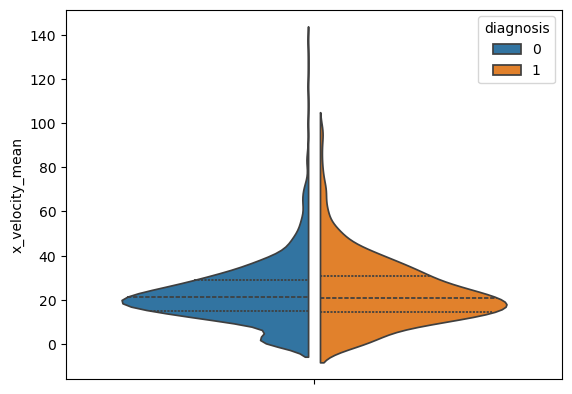

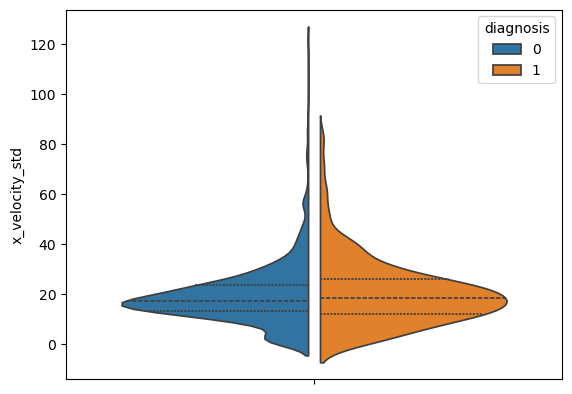

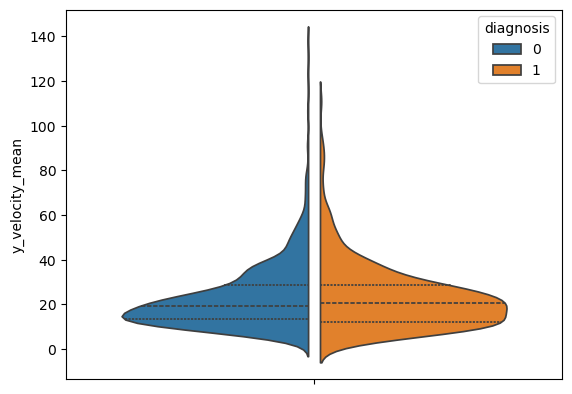

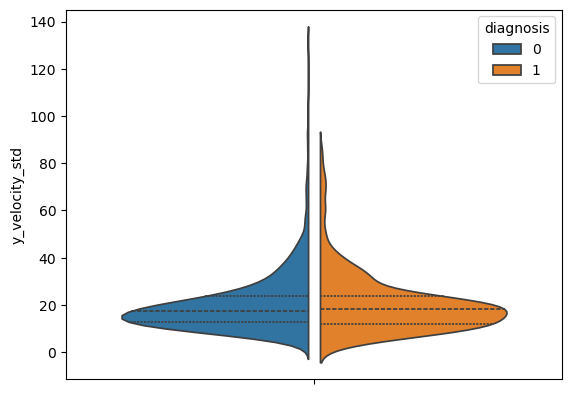

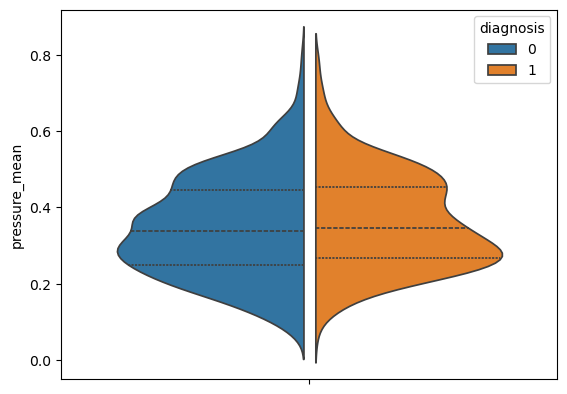

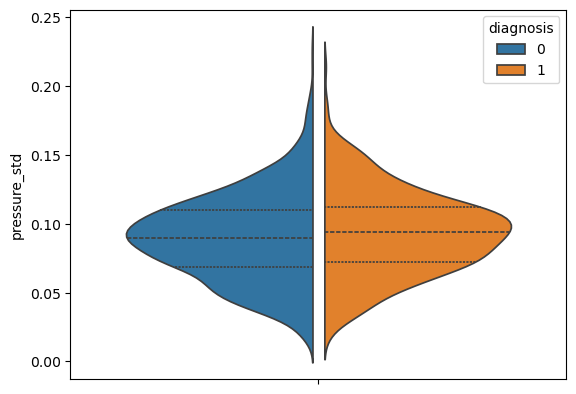

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [81]:
# Mann-Whitney U test on task 1_1
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_1_1 = df_hc_task1_1["x_velocity_mean"]
preLBD_xvel_mean_1_1 = df_preLBD_task1_1["x_velocity_mean"]

stat_xvel_mean_1_1, p_xvel_mean_1_1 = mannwhitneyu(hc_xvel_mean_1_1, preLBD_xvel_mean_1_1, alternative='two-sided')
stat_ks_xvel_mean_1_1, p_ks_xvel_mean_1_1 = ks_2samp(hc_xvel_mean_1_1, preLBD_xvel_mean_1_1)

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_1_1}, p-value={p_xvel_mean_1_1}")
print(f"KS Test for X-axis Velocity Mean: U-statistic={stat_ks_xvel_mean_1_1}, p-value={p_ks_xvel_mean_1_1}")
## X - axis velocity std

hc_xvel_std_1_1 = df_hc_task1_1["x_velocity_std"]
preLBD_xvel_std_1_1 = df_preLBD_task1_1["x_velocity_std"]

stat_xvel_std_1_1, p_xvel_std_1_1 = mannwhitneyu(hc_xvel_std_1_1, preLBD_xvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_1_1}, p-value={p_xvel_std_1_1}")
## Y - axis velocity mean
hc_yvel_mean_1_1 = df_hc_task1_1["y_velocity_mean"]
preLBD_yvel_mean_1_1 = df_preLBD_task1_1["y_velocity_mean"]

stat_yvel_mean_1_1, p_yvel_mean_1_1 = mannwhitneyu(hc_yvel_mean_1_1, preLBD_yvel_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_1_1}, p-value={p_yvel_mean_1_1}")
## Y - axis velocity std
hc_yvel_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_yvel_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_yvel_std_1_1, p_yvel_std_1_1 = mannwhitneyu(hc_yvel_std_1_1, preLBD_yvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_1_1}, p-value={p_yvel_std_1_1}")
## Pressure mean
hc_pressure_mean_1_1 = df_hc_task1_1["pressure_mean"]
preLBD_pressure_mean_1_1 = df_preLBD_task1_1["pressure_mean"]

stat_pressure_mean_1_1, p_pressure_mean_1_1 = mannwhitneyu(hc_pressure_mean_1_1, preLBD_pressure_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_1_1}, p-value={p_pressure_mean_1_1}")
## Pressure std
hc_pressure_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_pressure_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_pressure_std_1_1, p_pressure_std_1_1 = mannwhitneyu(hc_pressure_std_1_1, preLBD_pressure_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_1_1}, p-value={p_pressure_std_1_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=2141.0, p-value=0.22830968603668178
KS Test for X-axis Velocity Mean: U-statistic=0.15709728867623604, p-value=0.49692500983712057
Mann-Whitney U Test for X-axis Velocity std: U-statistic=2147.0, p-value=0.21773273706229135
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=2130.0, p-value=0.24864075721470347
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=2134.0, p-value=0.2411058964896864
Mann-Whitney U Test for Pressure Mean: U-statistic=1654.0, p-value=0.2930186743258284
Mann-Whitney U Test for Pressure std: U-statistic=2134.0, p-value=0.2411058964896864


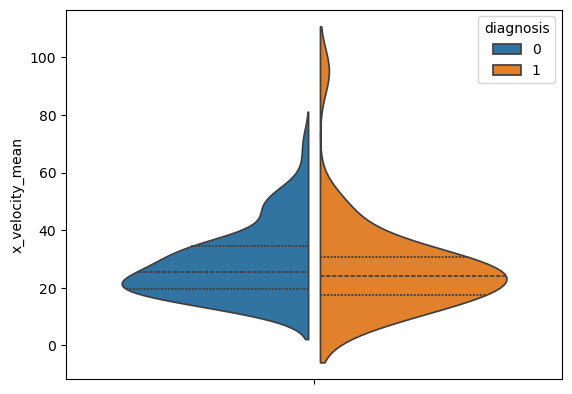

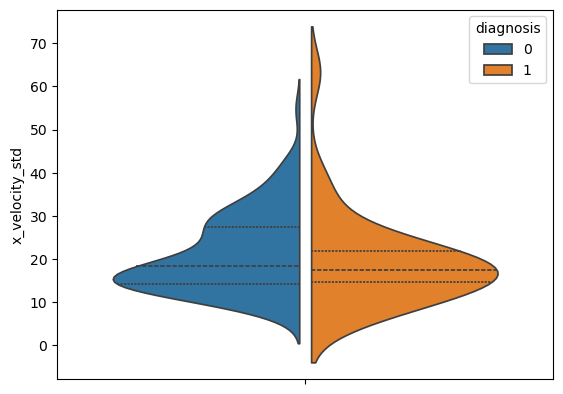

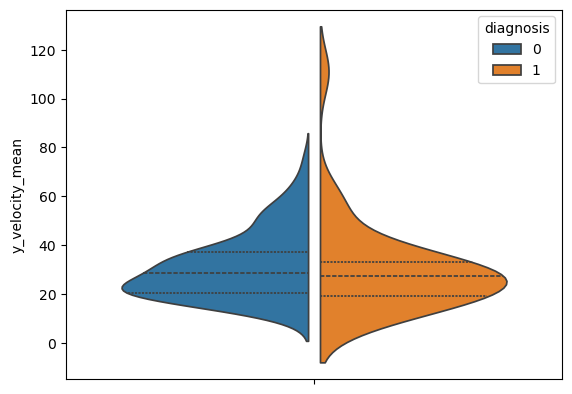

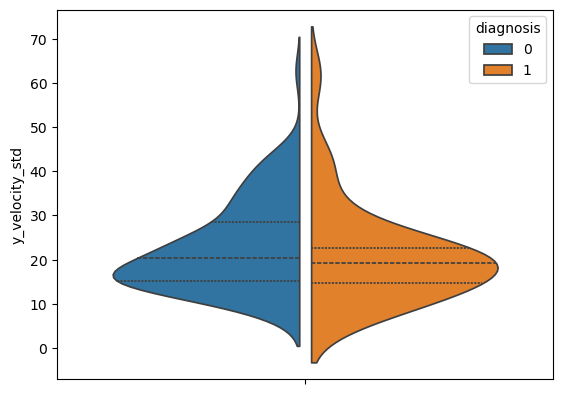

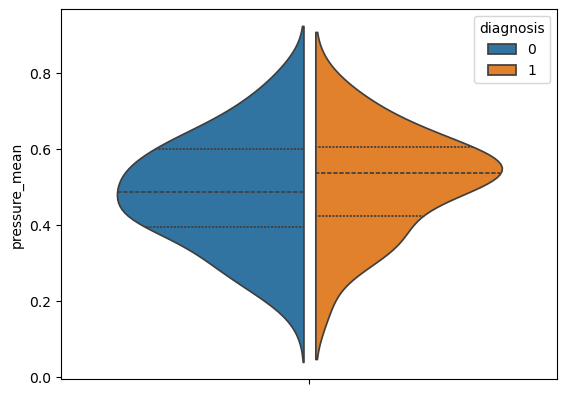

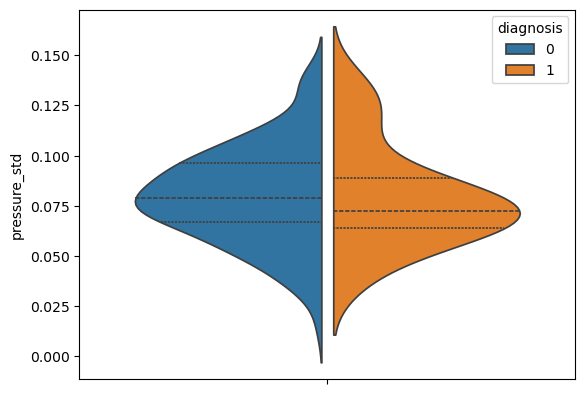

In [54]:
## Visualizations task 1_1
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task1_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task1_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task1_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task1_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task1_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task1_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [55]:


# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_3_1 = df_hc_task3_1["x_velocity_mean"]
preLBD_xvel_mean_3_1 = df_preLBD_task3_1["x_velocity_mean"]

stat_xvel_mean_3_1, p_xvel_mean_3_1 = mannwhitneyu(hc_xvel_mean_3_1, preLBD_xvel_mean_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_3_1}, p-value={p_xvel_mean_3_1}")
## X - axis velocity std

hc_xvel_std_3_1 = df_hc_task3_1["x_velocity_std"]
preLBD_xvel_std_3_1 = df_preLBD_task3_1["x_velocity_std"]

stat_xvel_std_3_1, p_xvel_std_3_1 = mannwhitneyu(hc_xvel_std_3_1, preLBD_xvel_std_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_3_1}, p-value={p_xvel_std_3_1}")
## Y - axis velocity mean
hc_yvel_mean_3_1 = df_hc_task3_1["y_velocity_mean"]
preLBD_yvel_mean_3_1 = df_preLBD_task3_1["y_velocity_mean"]

stat_yvel_mean_3_1, p_yvel_mean_3_1 = mannwhitneyu(hc_yvel_mean_3_1, preLBD_yvel_mean_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_3_1}, p-value={p_yvel_mean_3_1}")
## Y - axis velocity std
hc_yvel_std_3_1 = df_hc_task3_1["y_velocity_std"]
preLBD_yvel_std_3_1 = df_preLBD_task3_1["y_velocity_std"]

stat_yvel_std_3_1, p_yvel_std_3_1 = mannwhitneyu(hc_yvel_std_3_1, preLBD_yvel_std_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_3_1}, p-value={p_yvel_std_3_1}")
## Pressure mean
hc_pressure_mean_3_1 = df_hc_task3_1["pressure_mean"]
preLBD_pressure_mean_3_1 = df_preLBD_task3_1["pressure_mean"]

stat_pressure_mean_3_1, p_pressure_mean_3_1 = mannwhitneyu(hc_pressure_mean_3_1, preLBD_pressure_mean_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_3_1}, p-value={p_pressure_mean_3_1}")
## Pressure std
hc_pressure_std_3_1 = df_hc_task3_1["y_velocity_std"]
preLBD_pressure_std_3_1 = df_preLBD_task3_1["y_velocity_std"]

stat_pressure_std_3_1, p_pressure_std_3_1 = mannwhitneyu(hc_pressure_std_3_1, preLBD_pressure_std_3_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_3_1}, p-value={p_pressure_std_3_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=2082.0, p-value=0.3519477462200954
Mann-Whitney U Test for X-axis Velocity std: U-statistic=2024.0, p-value=0.5082571603573263
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=2112.0, p-value=0.2845776977141936
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=2059.0, p-value=0.4099163627495239
Mann-Whitney U Test for Pressure Mean: U-statistic=1951.0, p-value=0.746958350413957
Mann-Whitney U Test for Pressure std: U-statistic=2059.0, p-value=0.4099163627495239


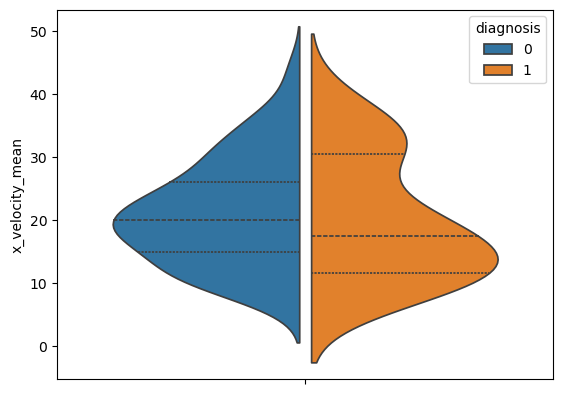

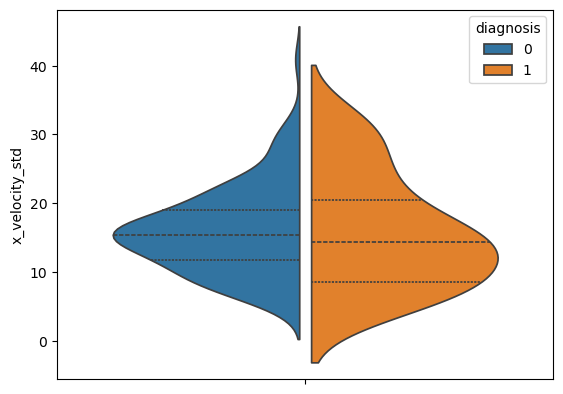

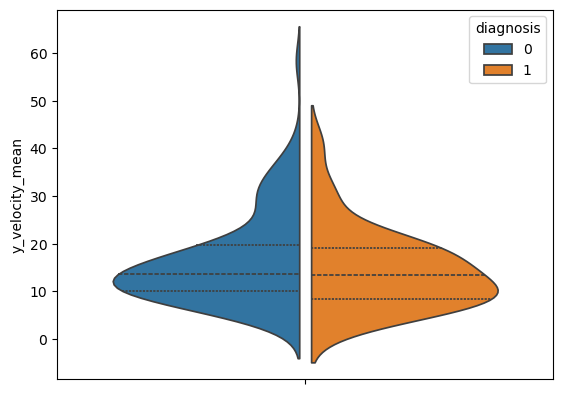

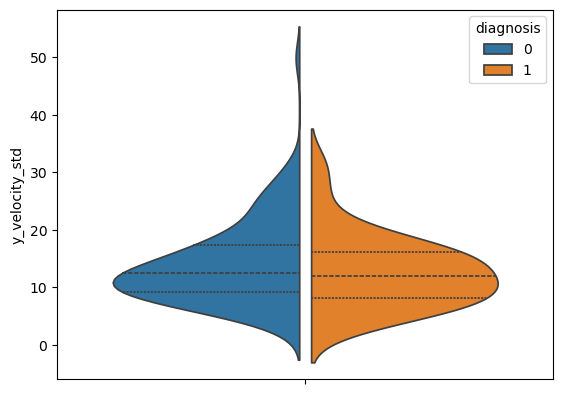

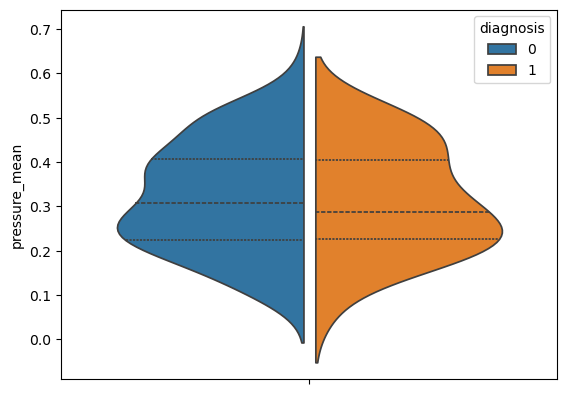

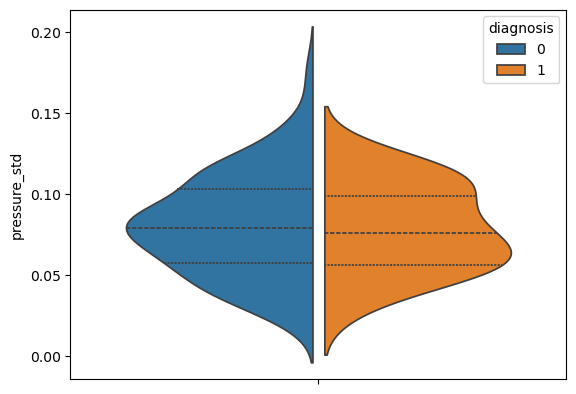

In [56]:

## Visualizations task 1_1
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task3_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [57]:



# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_3_2 = df_hc_task3_2["x_velocity_mean"]
preLBD_xvel_mean_3_2 = df_preLBD_task3_2["x_velocity_mean"]

stat_xvel_mean_3_2, p_xvel_mean_3_2 = mannwhitneyu(hc_xvel_mean_3_2, preLBD_xvel_mean_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_3_2}, p-value={p_xvel_mean_3_2}")
## X - axis velocity std

hc_xvel_std_3_2 = df_hc_task3_2["x_velocity_std"]
preLBD_xvel_std_3_2 = df_preLBD_task3_2["x_velocity_std"]

stat_xvel_std_3_2, p_xvel_std_3_2 = mannwhitneyu(hc_xvel_std_3_2, preLBD_xvel_std_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_3_2}, p-value={p_xvel_std_3_2}")
## Y - axis velocity mean
hc_yvel_mean_3_2 = df_hc_task3_2["y_velocity_mean"]
preLBD_yvel_mean_3_2 = df_preLBD_task3_2["y_velocity_mean"]

stat_yvel_mean_3_2, p_yvel_mean_3_2 = mannwhitneyu(hc_yvel_mean_3_2, preLBD_yvel_mean_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_3_2}, p-value={p_yvel_mean_3_2}")
## Y - axis velocity std
hc_yvel_std_3_2 = df_hc_task3_2["y_velocity_std"]
preLBD_yvel_std_3_2 = df_preLBD_task3_2["y_velocity_std"]

stat_yvel_std_3_2, p_yvel_std_3_2 = mannwhitneyu(hc_yvel_std_3_2, preLBD_yvel_std_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_3_2}, p-value={p_yvel_std_3_2}")
## Pressure mean
hc_pressure_mean_3_2 = df_hc_task3_2["pressure_mean"]
preLBD_pressure_mean_3_2 = df_preLBD_task3_2["pressure_mean"]

stat_pressure_mean_3_2, p_pressure_mean_3_2 = mannwhitneyu(hc_pressure_mean_3_2, preLBD_pressure_mean_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_3_2}, p-value={p_pressure_mean_3_2}")
## Pressure std
hc_pressure_std_3_2 = df_hc_task3_2["y_velocity_std"]
preLBD_pressure_std_3_2 = df_preLBD_task3_2["y_velocity_std"]

stat_pressure_std_3_2, p_pressure_std_3_2 = mannwhitneyu(hc_pressure_std_3_2, preLBD_pressure_std_3_2, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_3_2}, p-value={p_pressure_std_3_2}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1983.0, p-value=0.6374892957854358
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1855.0, p-value=0.9057639340372197
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1959.0, p-value=0.7190023332381621
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1949.0, p-value=0.7540013689163223
Mann-Whitney U Test for Pressure Mean: U-statistic=1803.0, p-value=0.7190023332381621
Mann-Whitney U Test for Pressure std: U-statistic=1949.0, p-value=0.7540013689163223


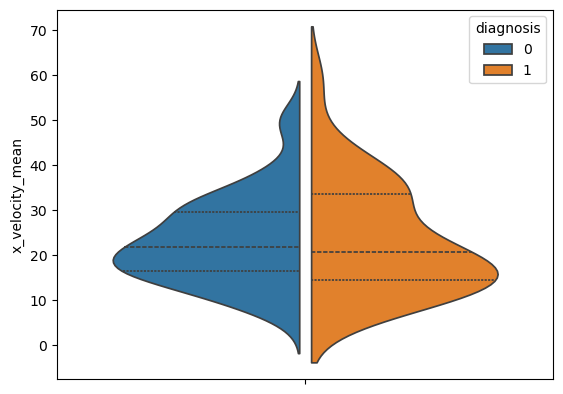

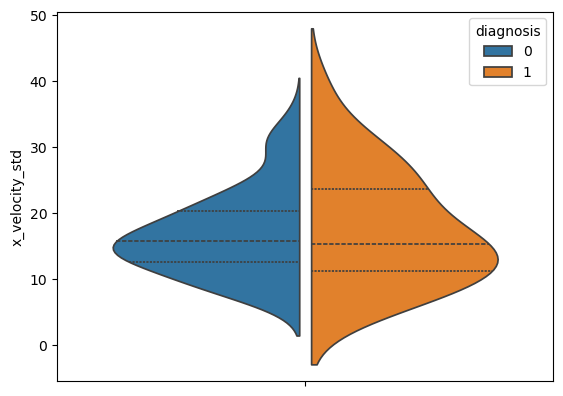

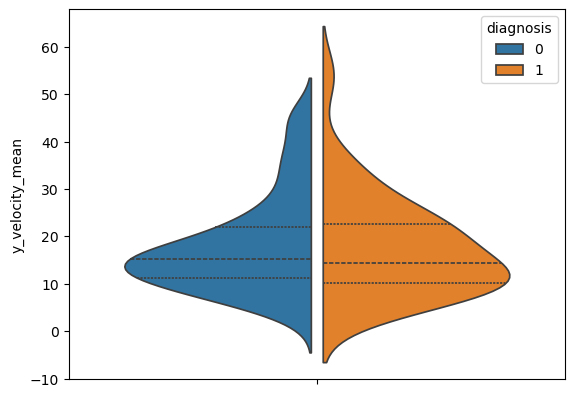

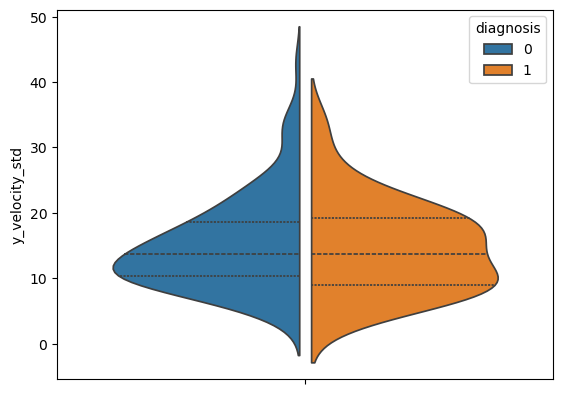

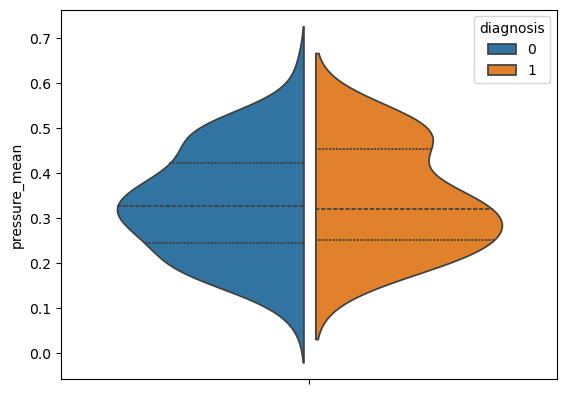

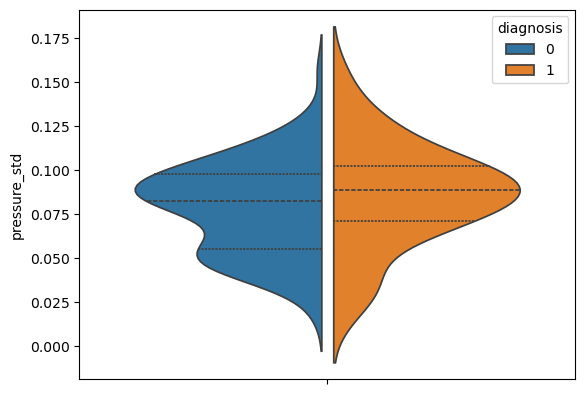

In [58]:

## Visualizations task 1_1
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task3_2, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_2, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_2, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_2, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_2, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_2, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [62]:

# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_3_3 = df_hc_task3_3["x_velocity_mean"]
preLBD_xvel_mean_3_3 = df_preLBD_task3_3["x_velocity_mean"]

stat_xvel_mean_3_3, p_xvel_mean_3_3 = mannwhitneyu(hc_xvel_mean_3_3, preLBD_xvel_mean_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_3_3}, p-value={p_xvel_mean_3_3}")
## X - axis velocity std

hc_xvel_std_3_3 = df_hc_task3_3["x_velocity_std"]
preLBD_xvel_std_3_3 = df_preLBD_task3_3["x_velocity_std"]

stat_xvel_std_3_3, p_xvel_std_3_3 = mannwhitneyu(hc_xvel_std_3_3, preLBD_xvel_std_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_3_3}, p-value={p_xvel_std_3_3}")
## Y - axis velocity mean
hc_yvel_mean_3_3 = df_hc_task3_3["y_velocity_mean"]
preLBD_yvel_mean_3_3 = df_preLBD_task3_3["y_velocity_mean"]

stat_yvel_mean_3_3, p_yvel_mean_3_3 = mannwhitneyu(hc_yvel_mean_3_3, preLBD_yvel_mean_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_3_3}, p-value={p_yvel_mean_3_3}")
## Y - axis velocity std
hc_yvel_std_3_3 = df_hc_task3_3["y_velocity_std"]
preLBD_yvel_std_3_3 = df_preLBD_task3_3["y_velocity_std"]

stat_yvel_std_3_3, p_yvel_std_3_3 = mannwhitneyu(hc_yvel_std_3_3, preLBD_yvel_std_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_3_3}, p-value={p_yvel_std_3_3}")
## Pressure mean
hc_pressure_mean_3_3 = df_hc_task3_3["pressure_mean"]
preLBD_pressure_mean_3_3 = df_preLBD_task3_3["pressure_mean"]

stat_pressure_mean_3_3, p_pressure_mean_3_3 = mannwhitneyu(hc_pressure_mean_3_3, preLBD_pressure_mean_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_3_3}, p-value={p_pressure_mean_3_3}")
## Pressure std
hc_pressure_std_3_3 = df_hc_task3_3["y_velocity_std"]
preLBD_pressure_std_3_3 = df_preLBD_task3_3["y_velocity_std"]

stat_pressure_std_3_3, p_pressure_std_3_3 = mannwhitneyu(hc_pressure_std_3_3, preLBD_pressure_std_3_3, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_3_3}, p-value={p_pressure_std_3_3}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=2007.0, p-value=0.5601412738952865
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1990.0, p-value=0.6144655591560079
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1990.0, p-value=0.6144655591560079
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1986.0, p-value=0.6275773753684217
Mann-Whitney U Test for Pressure Mean: U-statistic=1681.0, p-value=0.3543548034210917
Mann-Whitney U Test for Pressure std: U-statistic=1986.0, p-value=0.6275773753684217


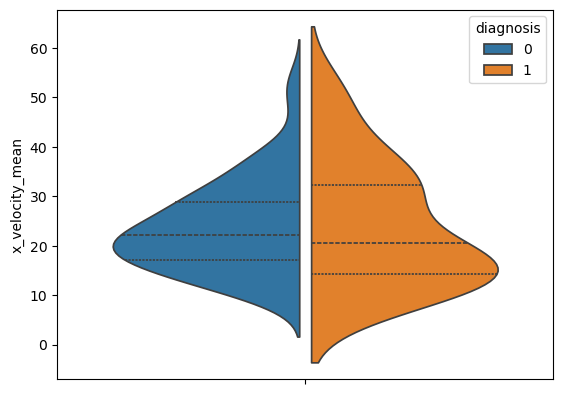

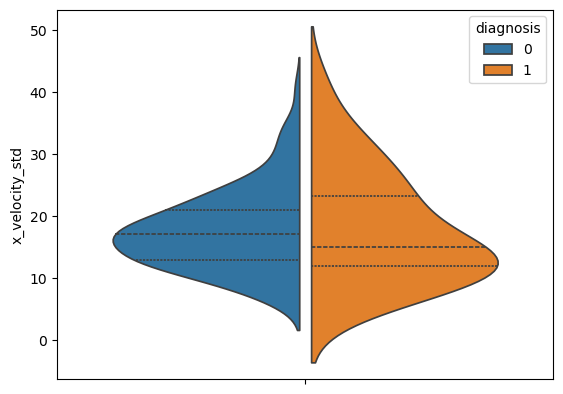

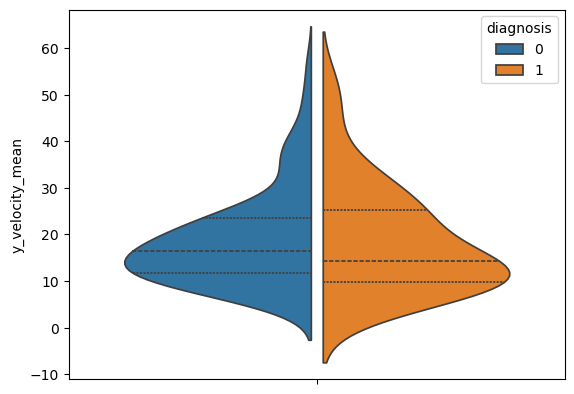

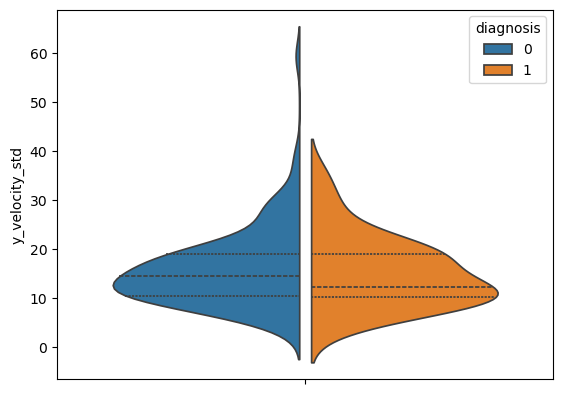

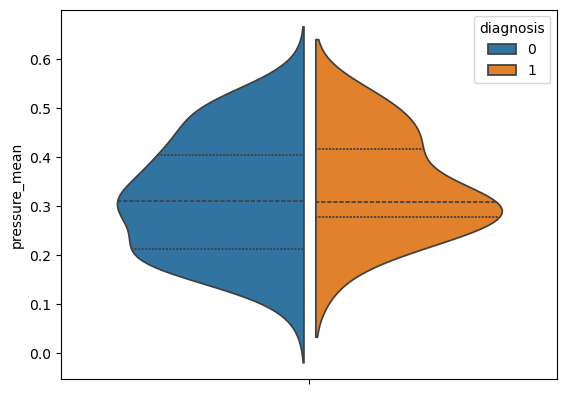

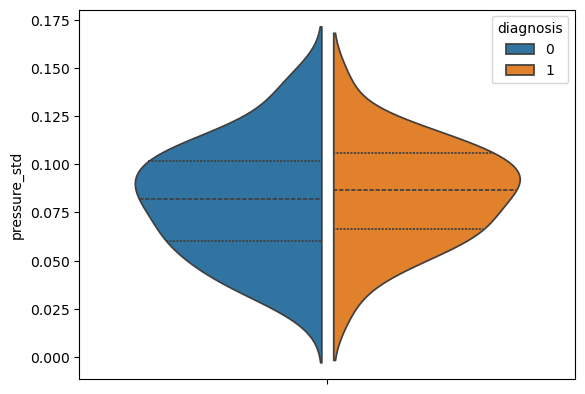

In [59]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task3_3, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_3, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_3, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_3, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_3, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_3, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [61]:


# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_3_4 = df_hc_task3_4["x_velocity_mean"]
preLBD_xvel_mean_3_4 = df_preLBD_task3_4["x_velocity_mean"]

stat_xvel_mean_3_4, p_xvel_mean_3_4 = mannwhitneyu(hc_xvel_mean_3_4, preLBD_xvel_mean_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_3_4}, p-value={p_xvel_mean_3_4}")
## X - axis velocity std

hc_xvel_std_3_4 = df_hc_task3_4["x_velocity_std"]
preLBD_xvel_std_3_4 = df_preLBD_task3_4["x_velocity_std"]

stat_xvel_std_3_4, p_xvel_std_3_4 = mannwhitneyu(hc_xvel_std_3_4, preLBD_xvel_std_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_3_4}, p-value={p_xvel_std_3_4}")
## Y - axis velocity mean
hc_yvel_mean_3_4 = df_hc_task3_4["y_velocity_mean"]
preLBD_yvel_mean_3_4 = df_preLBD_task3_4["y_velocity_mean"]

stat_yvel_mean_3_4, p_yvel_mean_3_4 = mannwhitneyu(hc_yvel_mean_3_4, preLBD_yvel_mean_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_3_4}, p-value={p_yvel_mean_3_4}")
## Y - axis velocity std
hc_yvel_std_3_4 = df_hc_task3_4["y_velocity_std"]
preLBD_yvel_std_3_4 = df_preLBD_task3_4["y_velocity_std"]

stat_yvel_std_3_4, p_yvel_std_3_4 = mannwhitneyu(hc_yvel_std_3_4, preLBD_yvel_std_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_3_4}, p-value={p_yvel_std_3_4}")
## Pressure mean
hc_pressure_mean_3_4 = df_hc_task3_4["pressure_mean"]
preLBD_pressure_mean_3_4 = df_preLBD_task3_4["pressure_mean"]

stat_pressure_mean_3_4, p_pressure_mean_3_4 = mannwhitneyu(hc_pressure_mean_3_4, preLBD_pressure_mean_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_3_4}, p-value={p_pressure_mean_3_4}")
## Pressure std
hc_pressure_std_3_4 = df_hc_task3_4["y_velocity_std"]
preLBD_pressure_std_3_4 = df_preLBD_task3_4["y_velocity_std"]

stat_pressure_std_3_4, p_pressure_std_3_4 = mannwhitneyu(hc_pressure_std_3_4, preLBD_pressure_std_3_4, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_3_4}, p-value={p_pressure_std_3_4}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1917.0, p-value=0.8690949775257877
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1821.0, p-value=0.782373130226635
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1923.0, p-value=0.8472228508248666
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1986.0, p-value=0.6275773753684217
Mann-Whitney U Test for Pressure Mean: U-statistic=1734.0, p-value=0.4964260542303168
Mann-Whitney U Test for Pressure std: U-statistic=1986.0, p-value=0.6275773753684217


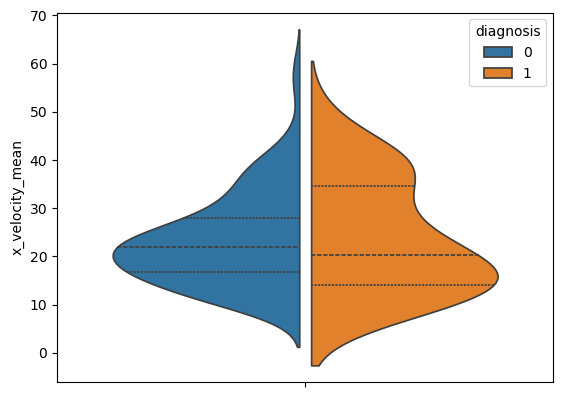

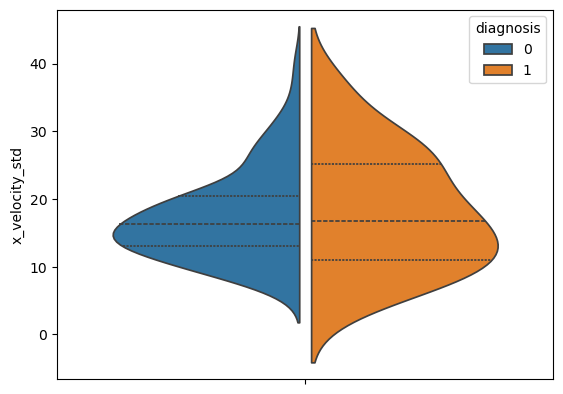

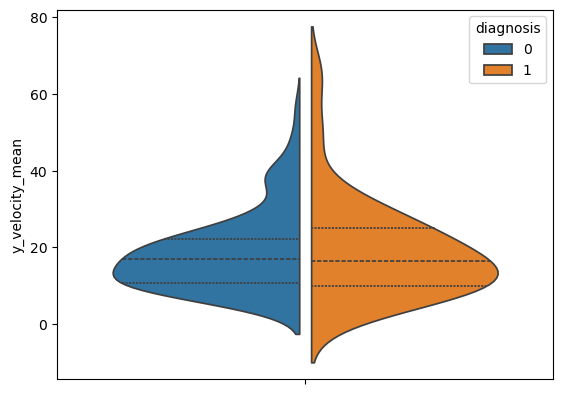

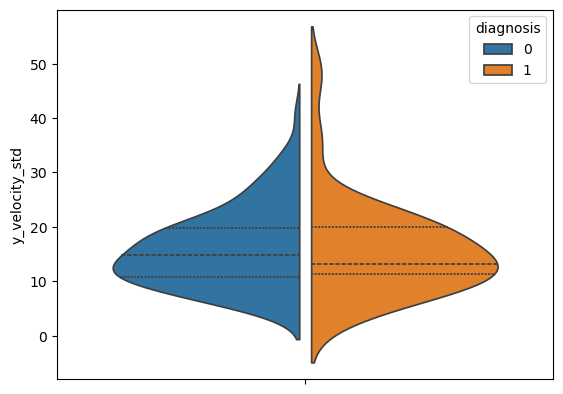

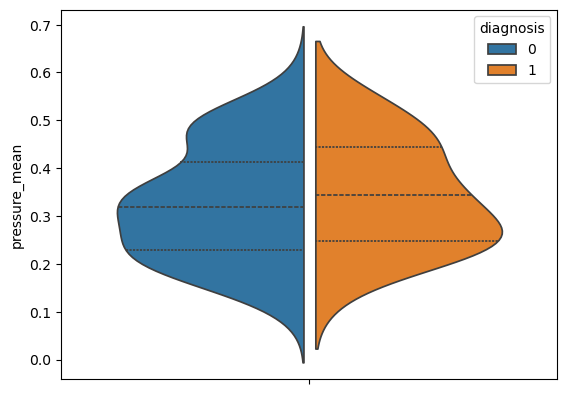

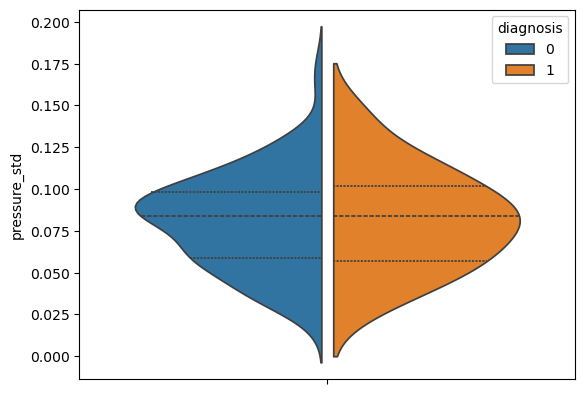

In [63]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task3_4, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_4, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_4, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_4, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_4, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_4, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [64]:

# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_3_5 = df_hc_task3_5["x_velocity_mean"]
preLBD_xvel_mean_3_5 = df_preLBD_task3_5["x_velocity_mean"]

stat_xvel_mean_3_5, p_xvel_mean_3_5 = mannwhitneyu(hc_xvel_mean_3_5, preLBD_xvel_mean_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_3_5}, p-value={p_xvel_mean_3_5}")
## X - axis velocity std

hc_xvel_std_3_5 = df_hc_task3_5["x_velocity_std"]
preLBD_xvel_std_3_5 = df_preLBD_task3_5["x_velocity_std"]

stat_xvel_std_3_5, p_xvel_std_3_5 = mannwhitneyu(hc_xvel_std_3_5, preLBD_xvel_std_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_3_5}, p-value={p_xvel_std_3_5}")
## Y - axis velocity mean
hc_yvel_mean_3_5 = df_hc_task3_5["y_velocity_mean"]
preLBD_yvel_mean_3_5 = df_preLBD_task3_5["y_velocity_mean"]

stat_yvel_mean_3_5, p_yvel_mean_3_5 = mannwhitneyu(hc_yvel_mean_3_5, preLBD_yvel_mean_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_3_5}, p-value={p_yvel_mean_3_5}")
## Y - axis velocity std
hc_yvel_std_3_5 = df_hc_task3_5["y_velocity_std"]
preLBD_yvel_std_3_5 = df_preLBD_task3_5["y_velocity_std"]

stat_yvel_std_3_5, p_yvel_std_3_5 = mannwhitneyu(hc_yvel_std_3_5, preLBD_yvel_std_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_3_5}, p-value={p_yvel_std_3_5}")
## Pressure mean
hc_pressure_mean_3_5 = df_hc_task3_5["pressure_mean"]
preLBD_pressure_mean_3_5 = df_preLBD_task3_5["pressure_mean"]

stat_pressure_mean_3_5, p_pressure_mean_3_5 = mannwhitneyu(hc_pressure_mean_3_5, preLBD_pressure_mean_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_3_5}, p-value={p_pressure_mean_3_5}")
## Pressure std
hc_pressure_std_3_5 = df_hc_task3_5["y_velocity_std"]
preLBD_pressure_std_3_5 = df_preLBD_task3_5["y_velocity_std"]

stat_pressure_std_3_5, p_pressure_std_3_5 = mannwhitneyu(hc_pressure_std_3_5, preLBD_pressure_std_3_5, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_3_5}, p-value={p_pressure_std_3_5}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1990.0, p-value=0.6144655591560079
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1917.0, p-value=0.8690949775257877
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1978.0, p-value=0.6541534429805521
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1951.0, p-value=0.746958350413957
Mann-Whitney U Test for Pressure Mean: U-statistic=1729.0, p-value=0.4818462239270199
Mann-Whitney U Test for Pressure std: U-statistic=1951.0, p-value=0.746958350413957


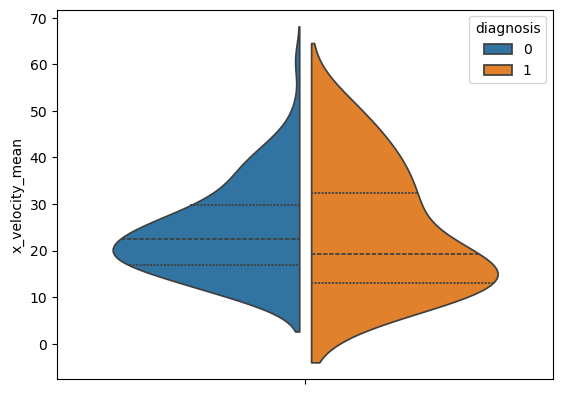

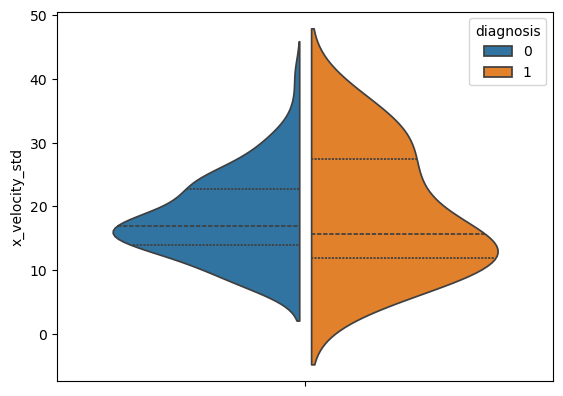

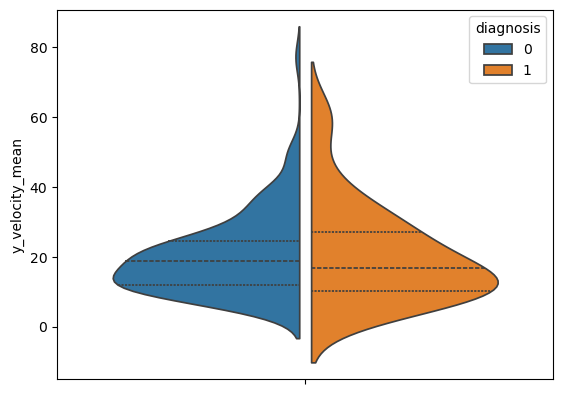

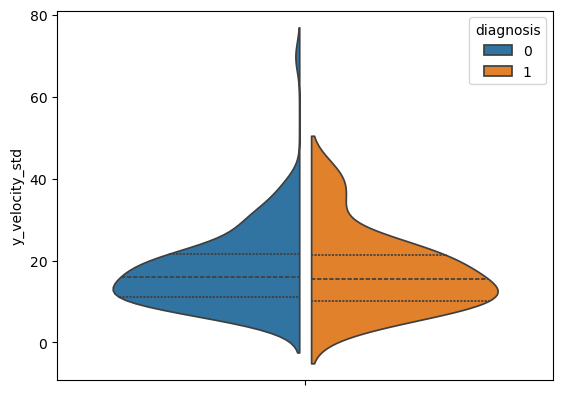

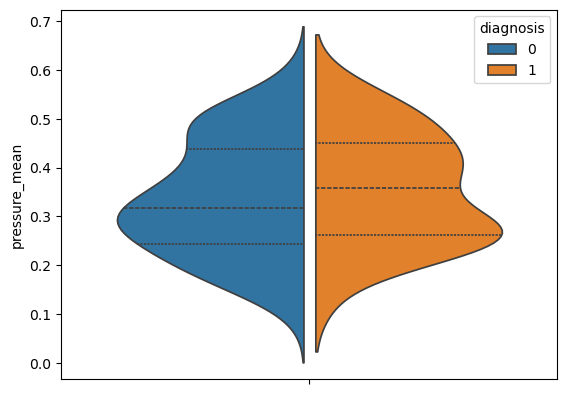

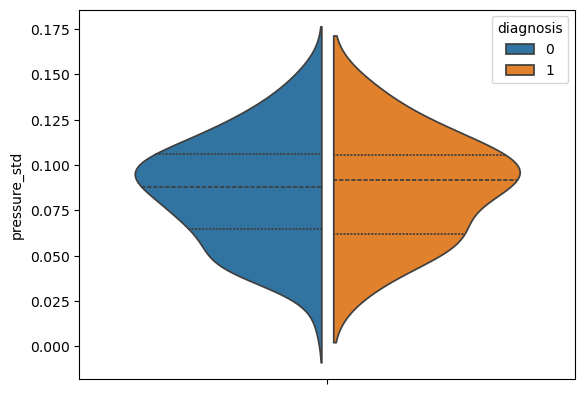

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task3_5, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_5, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_5, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_5, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_5, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task3_5, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [66]:

# Mann-Whitney U test 3_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_9_1 = df_hc_task9_1["x_velocity_mean"]
preLBD_xvel_mean_9_1 = df_preLBD_task9_1["x_velocity_mean"]

stat_xvel_mean_9_1, p_xvel_mean_9_1 = mannwhitneyu(hc_xvel_mean_9_1, preLBD_xvel_mean_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_9_1}, p-value={p_xvel_mean_9_1}")
## X - axis velocity std

hc_xvel_std_9_1 = df_hc_task9_1["x_velocity_std"]
preLBD_xvel_std_9_1 = df_preLBD_task9_1["x_velocity_std"]

stat_xvel_std_9_1, p_xvel_std_9_1 = mannwhitneyu(hc_xvel_std_9_1, preLBD_xvel_std_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_9_1}, p-value={p_xvel_std_9_1}")
## Y - axis velocity mean
hc_yvel_mean_9_1 = df_hc_task9_1["y_velocity_mean"]
preLBD_yvel_mean_9_1 = df_preLBD_task9_1["y_velocity_mean"]

stat_yvel_mean_9_1, p_yvel_mean_9_1 = mannwhitneyu(hc_yvel_mean_9_1, preLBD_yvel_mean_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_9_1}, p-value={p_yvel_mean_9_1}")
## Y - axis velocity std
hc_yvel_std_9_1 = df_hc_task9_1["y_velocity_std"]
preLBD_yvel_std_9_1 = df_preLBD_task9_1["y_velocity_std"]

stat_yvel_std_9_1, p_yvel_std_9_1 = mannwhitneyu(hc_yvel_std_9_1, preLBD_yvel_std_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_9_1}, p-value={p_yvel_std_9_1}")
## Pressure mean
hc_pressure_mean_9_1 = df_hc_task9_1["pressure_mean"]
preLBD_pressure_mean_9_1 = df_preLBD_task9_1["pressure_mean"]

stat_pressure_mean_9_1, p_pressure_mean_9_1 = mannwhitneyu(hc_pressure_mean_9_1, preLBD_pressure_mean_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_9_1}, p-value={p_pressure_mean_9_1}")
## Pressure std
hc_pressure_std_9_1 = df_hc_task9_1["y_velocity_std"]
preLBD_pressure_std_9_1 = df_preLBD_task9_1["y_velocity_std"]

stat_pressure_std_9_1, p_pressure_std_9_1 = mannwhitneyu(hc_pressure_std_9_1, preLBD_pressure_std_9_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_9_1}, p-value={p_pressure_std_9_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1848.0, p-value=0.610439306392222
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1765.0, p-value=0.9196259870022033
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1915.0, p-value=0.401338525453799
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1815.0, p-value=0.7285806010100739
Mann-Whitney U Test for Pressure Mean: U-statistic=1574.0, p-value=0.4041058136382889
Mann-Whitney U Test for Pressure std: U-statistic=1815.0, p-value=0.7285806010100739


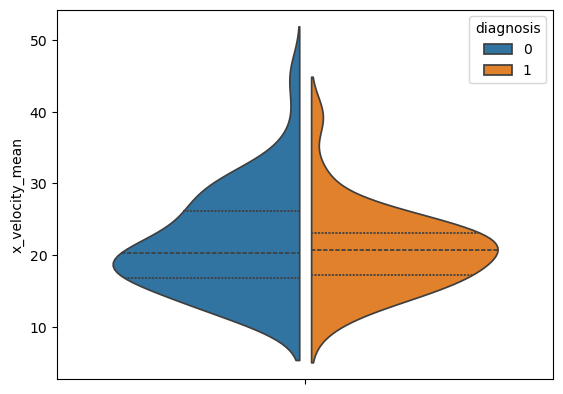

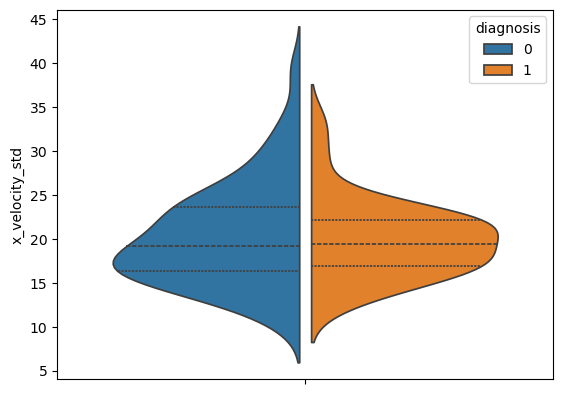

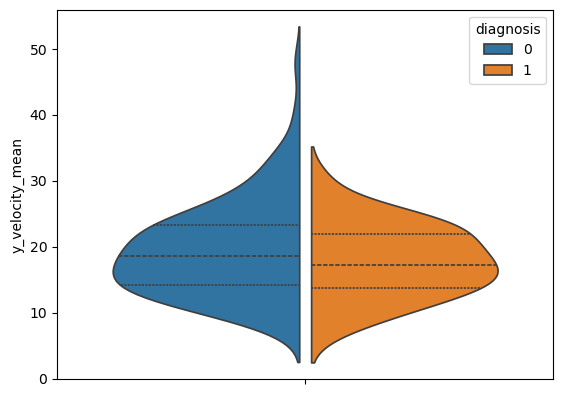

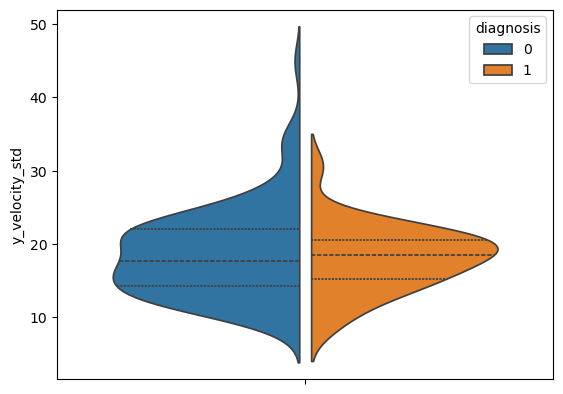

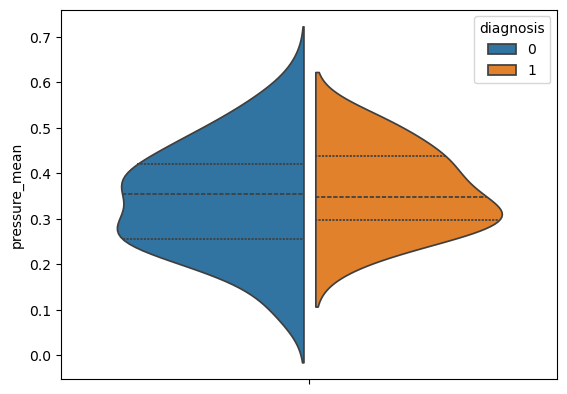

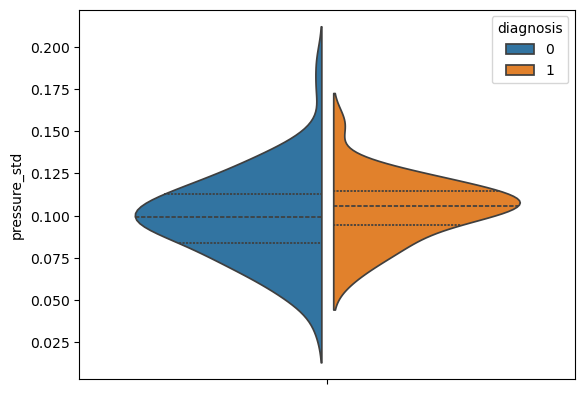

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task9_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task9_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task9_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task9_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task9_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task9_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [70]:
# Mann-Whitney U test 10_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_10_1 = df_hc_task10_1["x_velocity_mean"]
preLBD_xvel_mean_10_1 = df_preLBD_task10_1["x_velocity_mean"]

stat_xvel_mean_10_1, p_xvel_mean_10_1 = mannwhitneyu(hc_xvel_mean_10_1, preLBD_xvel_mean_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_10_1}, p-value={p_xvel_mean_10_1}")
## X - axis velocity std

hc_xvel_std_10_1 = df_hc_task9_1["x_velocity_std"]
preLBD_xvel_std_10_1 = df_preLBD_task10_1["x_velocity_std"]

stat_xvel_std_10_1, p_xvel_std_10_1 = mannwhitneyu(hc_xvel_std_10_1, preLBD_xvel_std_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_10_1}, p-value={p_xvel_std_10_1}")
## Y - axis velocity mean
hc_yvel_mean_10_1 = df_hc_task10_1["y_velocity_mean"]
preLBD_yvel_mean_10_1 = df_preLBD_task10_1["y_velocity_mean"]

stat_yvel_mean_10_1, p_yvel_mean_10_1 = mannwhitneyu(hc_yvel_mean_10_1, preLBD_yvel_mean_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_10_1}, p-value={p_yvel_mean_10_1}")
## Y - axis velocity std
hc_yvel_std_10_1 = df_hc_task10_1["y_velocity_std"]
preLBD_yvel_std_10_1 = df_preLBD_task10_1["y_velocity_std"]

stat_yvel_std_10_1, p_yvel_std_10_1 = mannwhitneyu(hc_yvel_std_10_1, preLBD_yvel_std_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_10_1}, p-value={p_yvel_std_10_1}")
## Pressure mean
hc_pressure_mean_10_1 = df_hc_task10_1["pressure_mean"]
preLBD_pressure_mean_10_1 = df_preLBD_task10_1["pressure_mean"]

stat_pressure_mean_10_1, p_pressure_mean_10_1 = mannwhitneyu(hc_pressure_mean_10_1, preLBD_pressure_mean_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_10_1}, p-value={p_pressure_mean_10_1}")
## Pressure std
hc_pressure_std_10_1 = df_hc_task10_1["y_velocity_std"]
preLBD_pressure_std_10_1 = df_preLBD_task10_1["y_velocity_std"]

stat_pressure_std_10_1, p_pressure_std_10_1 = mannwhitneyu(hc_pressure_std_10_1, preLBD_pressure_std_10_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_10_1}, p-value={p_pressure_std_10_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1963.0, p-value=0.7051613916538082
Mann-Whitney U Test for X-axis Velocity std: U-statistic=2216.0, p-value=0.04399542795040929
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1959.0, p-value=0.7190023332381621
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1973.0, p-value=0.6709917795474749
Mann-Whitney U Test for Pressure Mean: U-statistic=1784.0, p-value=0.6541534429805521
Mann-Whitney U Test for Pressure std: U-statistic=1973.0, p-value=0.6709917795474749


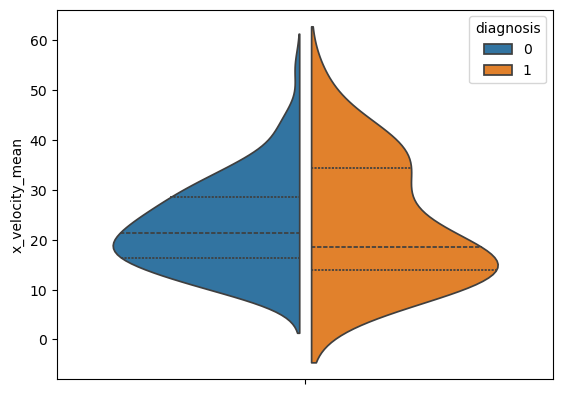

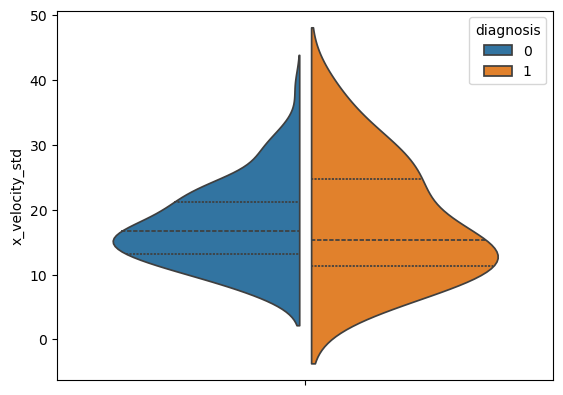

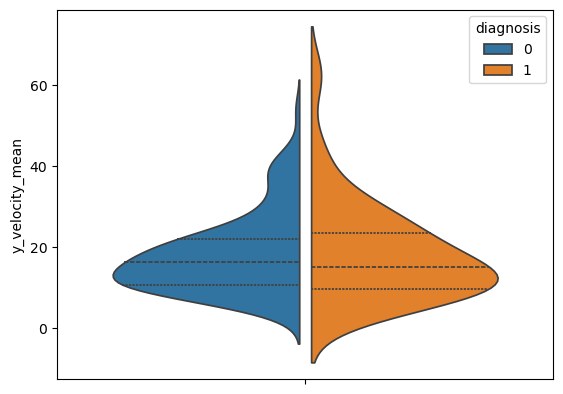

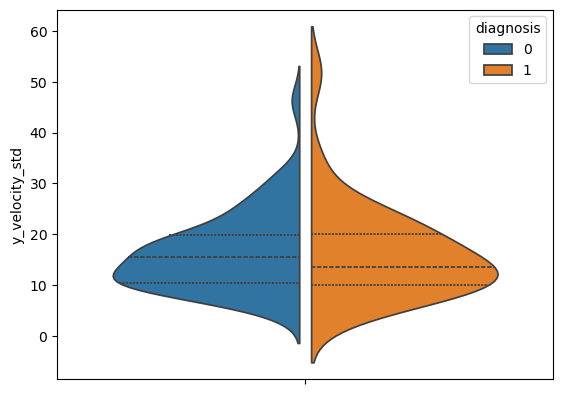

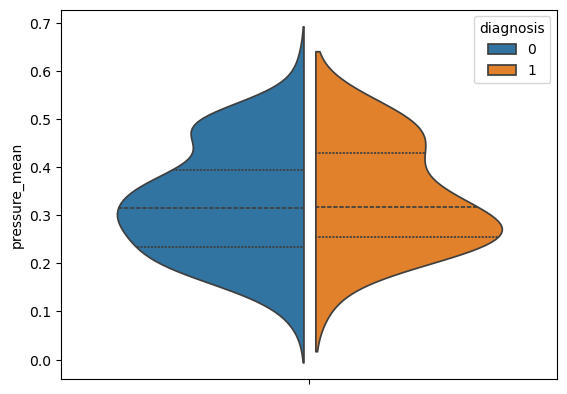

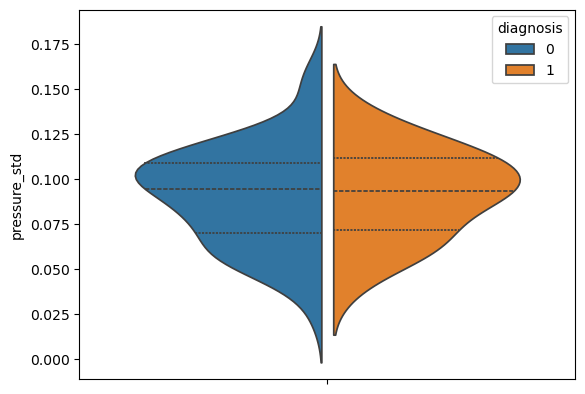

In [69]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task10_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task10_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task10_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task10_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task10_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task10_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task15_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task15_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task15_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task15_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task15_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task15_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [71]:

# Mann-Whitney U test 10_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_15_1 = df_hc_task15_1["x_velocity_mean"]
preLBD_xvel_mean_15_1 = df_preLBD_task15_1["x_velocity_mean"]

stat_xvel_mean_15_1, p_xvel_mean_15_1 = mannwhitneyu(hc_xvel_mean_15_1, preLBD_xvel_mean_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_15_1}, p-value={p_xvel_mean_15_1}")
## X - axis velocity std

hc_xvel_std_15_1 = df_hc_task15_1["x_velocity_std"]
preLBD_xvel_std_15_1 = df_preLBD_task15_1["x_velocity_std"]

stat_xvel_std_15_1, p_xvel_std_15_1 = mannwhitneyu(hc_xvel_std_15_1, preLBD_xvel_std_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_15_1}, p-value={p_xvel_std_15_1}")
## Y - axis velocity mean
hc_yvel_mean_15_1 = df_hc_task15_1["y_velocity_mean"]
preLBD_yvel_mean_15_1 = df_preLBD_task15_1["y_velocity_mean"]

stat_yvel_mean_15_1, p_yvel_mean_15_1 = mannwhitneyu(hc_yvel_mean_15_1, preLBD_yvel_mean_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_15_1}, p-value={p_yvel_mean_15_1}")
## Y - axis velocity std
hc_yvel_std_15_1 = df_hc_task15_1["y_velocity_std"]
preLBD_yvel_std_15_1 = df_preLBD_task15_1["y_velocity_std"]

stat_yvel_std_15_1, p_yvel_std_15_1 = mannwhitneyu(hc_yvel_std_15_1, preLBD_yvel_std_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_15_1}, p-value={p_yvel_std_15_1}")
## Pressure mean
hc_pressure_mean_15_1 = df_hc_task15_1["pressure_mean"]
preLBD_pressure_mean_15_1 = df_preLBD_task15_1["pressure_mean"]

stat_pressure_mean_15_1, p_pressure_mean_15_1 = mannwhitneyu(hc_pressure_mean_15_1, preLBD_pressure_mean_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_15_1}, p-value={p_pressure_mean_15_1}")
## Pressure std
hc_pressure_std_15_1 = df_hc_task15_1["y_velocity_std"]
preLBD_pressure_std_15_1 = df_preLBD_task15_1["y_velocity_std"]

stat_pressure_std_15_1, p_pressure_std_15_1 = mannwhitneyu(hc_pressure_std_15_1, preLBD_pressure_std_15_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_15_1}, p-value={p_pressure_std_15_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1753.0, p-value=0.5539064055406997
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1807.0, p-value=0.7329360575607657
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1729.0, p-value=0.4818462239270199
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1832.0, p-value=0.8218544556441085
Mann-Whitney U Test for Pressure Mean: U-statistic=1834.0, p-value=0.8290848081120731
Mann-Whitney U Test for Pressure std: U-statistic=1832.0, p-value=0.8218544556441085


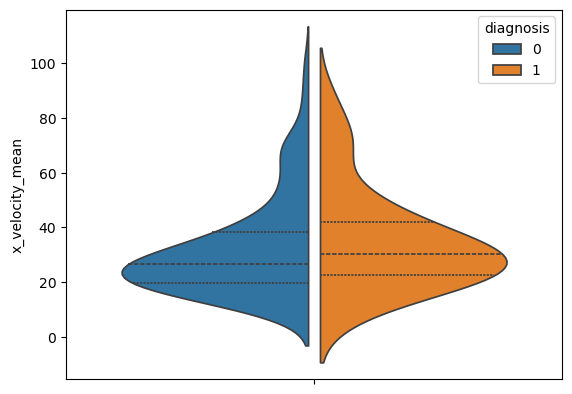

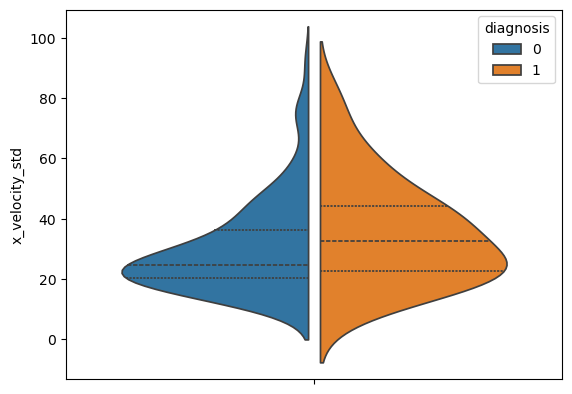

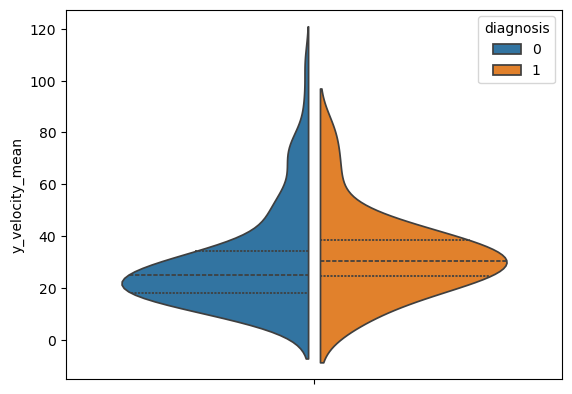

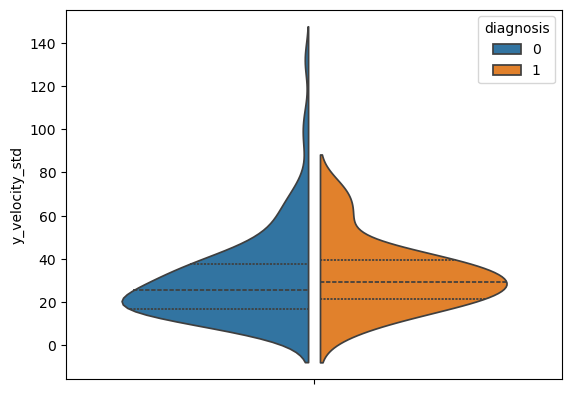

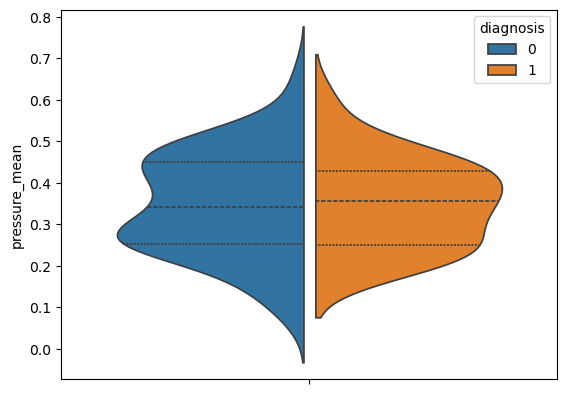

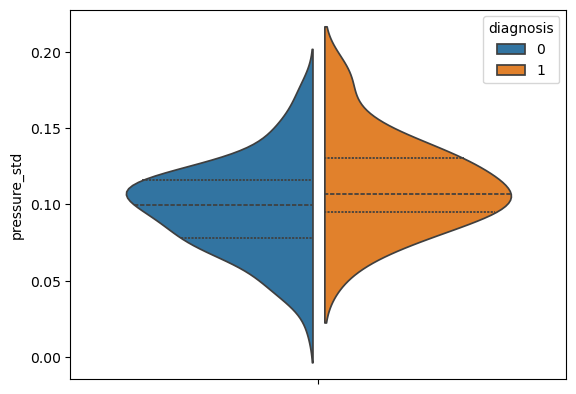

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task16_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task16_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task16_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task16_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task16_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task16_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [73]:
# Mann-Whitney U test 15_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_16_1 = df_hc_task16_1["x_velocity_mean"]
preLBD_xvel_mean_16_1 = df_preLBD_task16_1["x_velocity_mean"]

stat_xvel_mean_16_1, p_xvel_mean_16_1 = mannwhitneyu(hc_xvel_mean_16_1, preLBD_xvel_mean_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_16_1}, p-value={p_xvel_mean_16_1}")
## X - axis velocity std

hc_xvel_std_16_1 = df_hc_task16_1["x_velocity_std"]
preLBD_xvel_std_16_1 = df_preLBD_task16_1["x_velocity_std"]

stat_xvel_std_16_1, p_xvel_std_16_1 = mannwhitneyu(hc_xvel_std_16_1, preLBD_xvel_std_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_16_1}, p-value={p_xvel_std_16_1}")
## Y - axis velocity mean
hc_yvel_mean_16_1 = df_hc_task16_1["y_velocity_mean"]
preLBD_yvel_mean_16_1 = df_preLBD_task16_1["y_velocity_mean"]

stat_yvel_mean_16_1, p_yvel_mean_16_1 = mannwhitneyu(hc_yvel_mean_16_1, preLBD_yvel_mean_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_16_1}, p-value={p_yvel_mean_16_1}")
## Y - axis velocity std
hc_yvel_std_16_1 = df_hc_task16_1["y_velocity_std"]
preLBD_yvel_std_16_1 = df_preLBD_task16_1["y_velocity_std"]

stat_yvel_std_16_1, p_yvel_std_16_1 = mannwhitneyu(hc_yvel_std_16_1, preLBD_yvel_std_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_16_1}, p-value={p_yvel_std_16_1}")
## Pressure mean
hc_pressure_mean_16_1 = df_hc_task16_1["pressure_mean"]
preLBD_pressure_mean_16_1 = df_preLBD_task16_1["pressure_mean"]

stat_pressure_mean_16_1, p_pressure_mean_16_1 = mannwhitneyu(hc_pressure_mean_16_1, preLBD_pressure_mean_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_16_1}, p-value={p_pressure_mean_16_1}")
## Pressure std
hc_pressure_std_16_1 = df_hc_task16_1["y_velocity_std"]
preLBD_pressure_std_16_1 = df_preLBD_task16_1["y_velocity_std"]

stat_pressure_std_16_1, p_pressure_std_16_1 = mannwhitneyu(hc_pressure_std_16_1, preLBD_pressure_std_16_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_16_1}, p-value={p_pressure_std_16_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1620.0, p-value=0.22652189849713933
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1527.0, p-value=0.10077293947617227
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1522.0, p-value=0.0960464328639773
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1633.0, p-value=0.2505499322168335
Mann-Whitney U Test for Pressure Mean: U-statistic=1893.0, p-value=0.9574223197297036
Mann-Whitney U Test for Pressure std: U-statistic=1633.0, p-value=0.2505499322168335


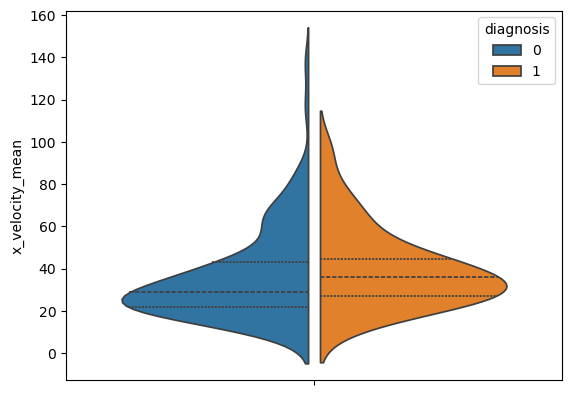

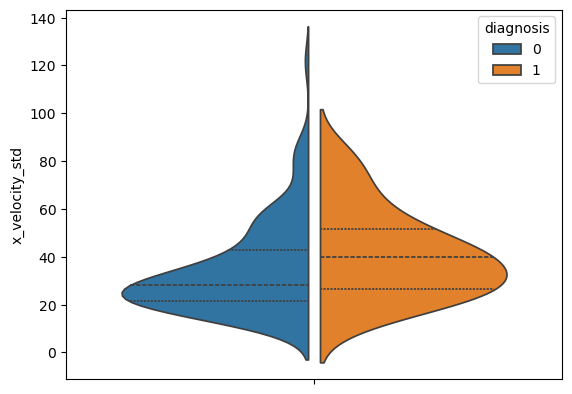

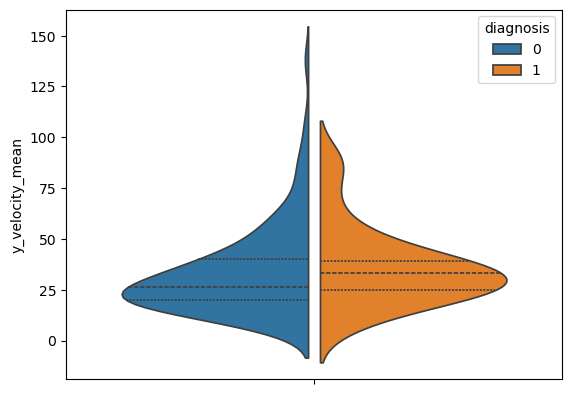

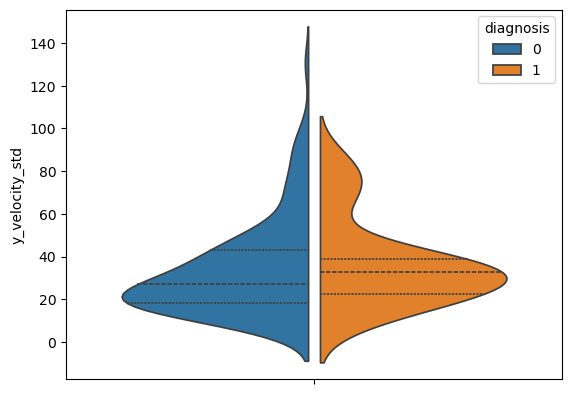

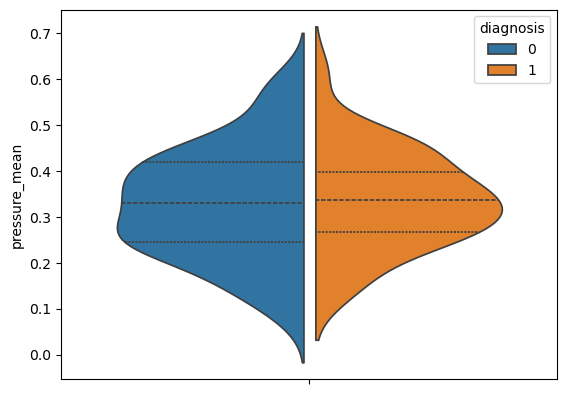

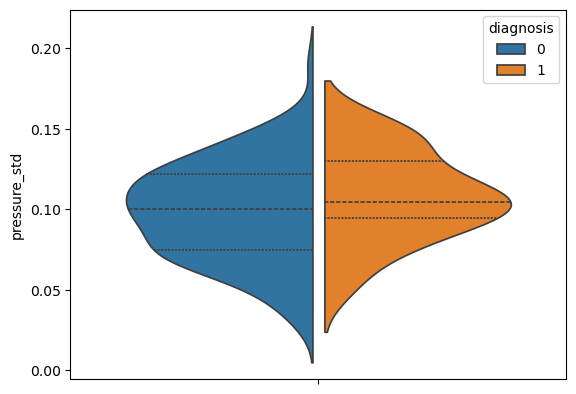

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task17_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task17_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task17_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task17_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task17_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task17_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [75]:

# Mann-Whitney U test 10_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_17_1 = df_hc_task17_1["x_velocity_mean"]
preLBD_xvel_mean_17_1 = df_preLBD_task17_1["x_velocity_mean"]

stat_xvel_mean_17_1, p_xvel_mean_17_1 = mannwhitneyu(hc_xvel_mean_17_1, preLBD_xvel_mean_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_17_1}, p-value={p_xvel_mean_17_1}")
## X - axis velocity std

hc_xvel_std_17_1 = df_hc_task17_1["x_velocity_std"]
preLBD_xvel_std_17_1 = df_preLBD_task17_1["x_velocity_std"]

stat_xvel_std_17_1, p_xvel_std_17_1 = mannwhitneyu(hc_xvel_std_17_1, preLBD_xvel_std_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_17_1}, p-value={p_xvel_std_17_1}")
## Y - axis velocity mean
hc_yvel_mean_17_1 = df_hc_task17_1["y_velocity_mean"]
preLBD_yvel_mean_17_1 = df_preLBD_task17_1["y_velocity_mean"]

stat_yvel_mean_17_1, p_yvel_mean_17_1 = mannwhitneyu(hc_yvel_mean_17_1, preLBD_yvel_mean_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_17_1}, p-value={p_yvel_mean_17_1}")
## Y - axis velocity std
hc_yvel_std_17_1 = df_hc_task17_1["y_velocity_std"]
preLBD_yvel_std_17_1 = df_preLBD_task17_1["y_velocity_std"]

stat_yvel_std_17_1, p_yvel_std_17_1 = mannwhitneyu(hc_yvel_std_17_1, preLBD_yvel_std_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_17_1}, p-value={p_yvel_std_17_1}")
## Pressure mean
hc_pressure_mean_17_1 = df_hc_task17_1["pressure_mean"]
preLBD_pressure_mean_17_1 = df_preLBD_task17_1["pressure_mean"]

stat_pressure_mean_17_1, p_pressure_mean_17_1 = mannwhitneyu(hc_pressure_mean_17_1, preLBD_pressure_mean_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_17_1}, p-value={p_pressure_mean_17_1}")
## Pressure std
hc_pressure_std_17_1 = df_hc_task17_1["y_velocity_std"]
preLBD_pressure_std_17_1 = df_preLBD_task17_1["y_velocity_std"]

stat_pressure_std_17_1, p_pressure_std_17_1 = mannwhitneyu(hc_pressure_std_17_1, preLBD_pressure_std_17_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_17_1}, p-value={p_pressure_std_17_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1510.0, p-value=0.08542514541058314
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1426.0, p-value=0.03485760178441932
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1595.0, p-value=0.18502888990022304
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1610.0, p-value=0.20919146931580646
Mann-Whitney U Test for Pressure Mean: U-statistic=1768.0, p-value=0.6014758136113565
Mann-Whitney U Test for Pressure std: U-statistic=1610.0, p-value=0.20919146931580646


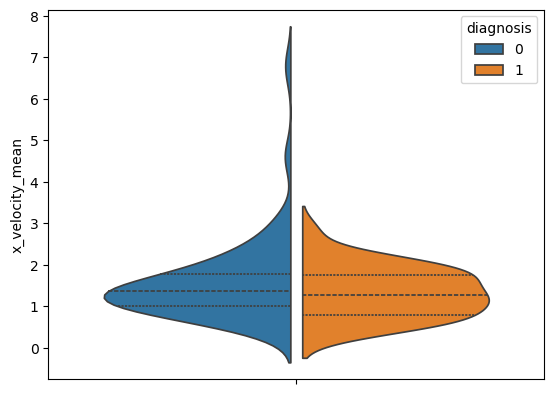

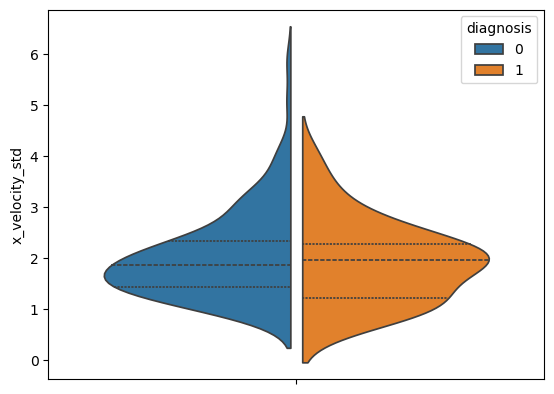

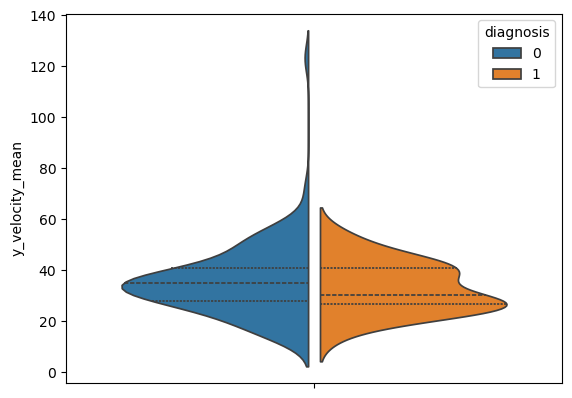

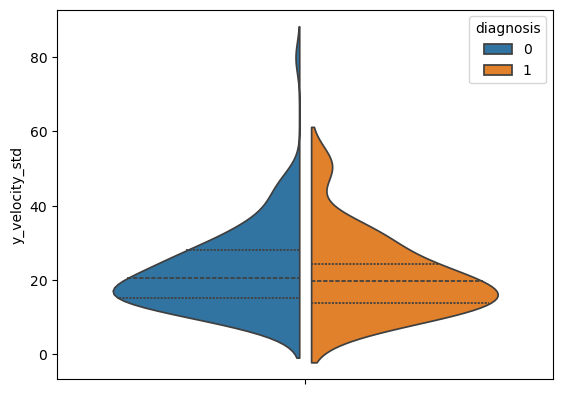

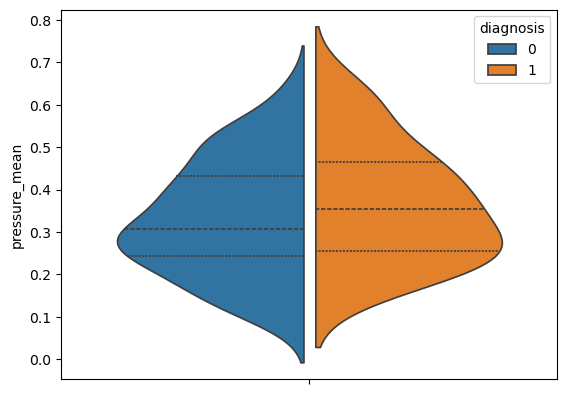

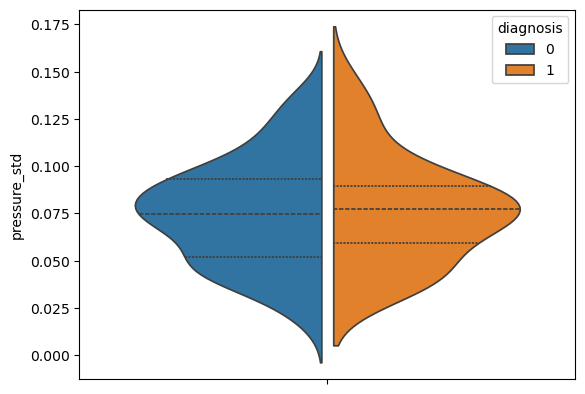

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task18_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task18_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task18_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task18_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task18_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task18_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [77]:

# Mann-Whitney U test 10_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_18_1 = df_hc_task18_1["x_velocity_mean"]
preLBD_xvel_mean_18_1 = df_preLBD_task18_1["x_velocity_mean"]

stat_xvel_mean_18_1, p_xvel_mean_18_1 = mannwhitneyu(hc_xvel_mean_18_1, preLBD_xvel_mean_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_18_1}, p-value={p_xvel_mean_18_1}")
## X - axis velocity std

hc_xvel_std_18_1 = df_hc_task18_1["x_velocity_std"]
preLBD_xvel_std_18_1 = df_preLBD_task18_1["x_velocity_std"]

stat_xvel_std_18_1, p_xvel_std_18_1 = mannwhitneyu(hc_xvel_std_18_1, preLBD_xvel_std_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_18_1}, p-value={p_xvel_std_18_1}")
## Y - axis velocity mean
hc_yvel_mean_18_1 = df_hc_task18_1["y_velocity_mean"]
preLBD_yvel_mean_18_1 = df_preLBD_task18_1["y_velocity_mean"]

stat_yvel_mean_18_1, p_yvel_mean_18_1 = mannwhitneyu(hc_yvel_mean_18_1, preLBD_yvel_mean_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_18_1}, p-value={p_yvel_mean_18_1}")
## Y - axis velocity std
hc_yvel_std_18_1 = df_hc_task18_1["y_velocity_std"]
preLBD_yvel_std_18_1 = df_preLBD_task18_1["y_velocity_std"]

stat_yvel_std_18_1, p_yvel_std_18_1 = mannwhitneyu(hc_yvel_std_18_1, preLBD_yvel_std_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_18_1}, p-value={p_yvel_std_18_1}")
## Pressure mean
hc_pressure_mean_18_1 = df_hc_task18_1["pressure_mean"]
preLBD_pressure_mean_18_1 = df_preLBD_task18_1["pressure_mean"]

stat_pressure_mean_18_1, p_pressure_mean_18_1 = mannwhitneyu(hc_pressure_mean_18_1, preLBD_pressure_mean_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_18_1}, p-value={p_pressure_mean_18_1}")
## Pressure std
hc_pressure_std_18_1 = df_hc_task18_1["y_velocity_std"]
preLBD_pressure_std_18_1 = df_preLBD_task18_1["y_velocity_std"]

stat_pressure_std_18_1, p_pressure_std_18_1 = mannwhitneyu(hc_pressure_std_18_1, preLBD_pressure_std_18_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_18_1}, p-value={p_pressure_std_18_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=2080.0, p-value=0.3567722326405949
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1992.0, p-value=0.6079552185417811
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=2079.0, p-value=0.35920002624580816
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=2053.0, p-value=0.4259239790605549
Mann-Whitney U Test for Pressure Mean: U-statistic=1667.0, p-value=0.32160246491574684
Mann-Whitney U Test for Pressure std: U-statistic=2053.0, p-value=0.4259239790605549


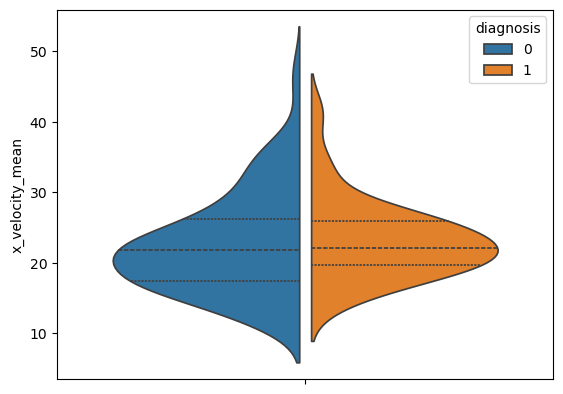

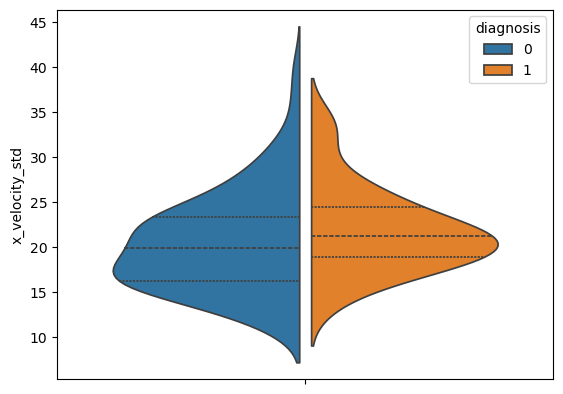

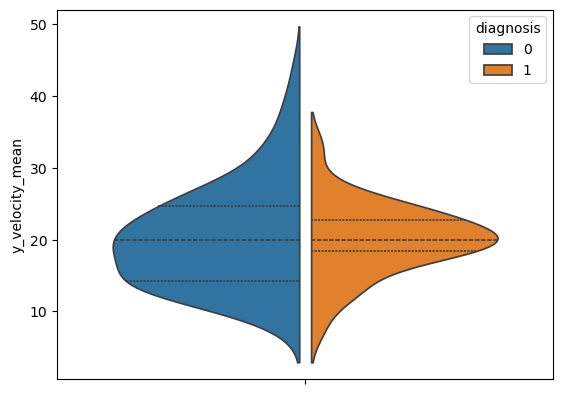

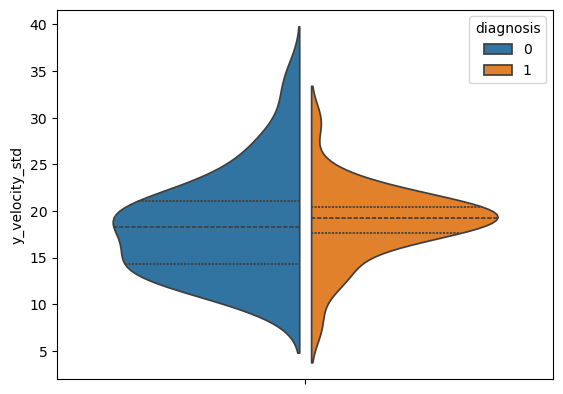

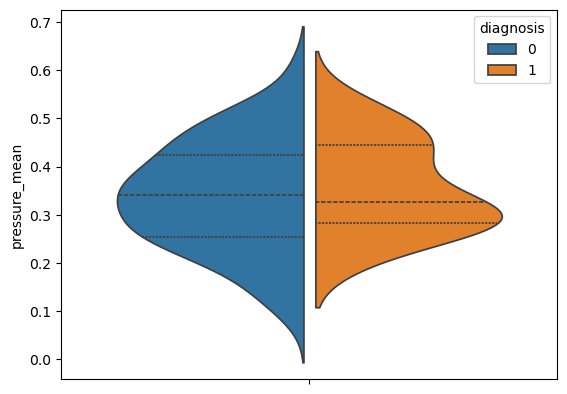

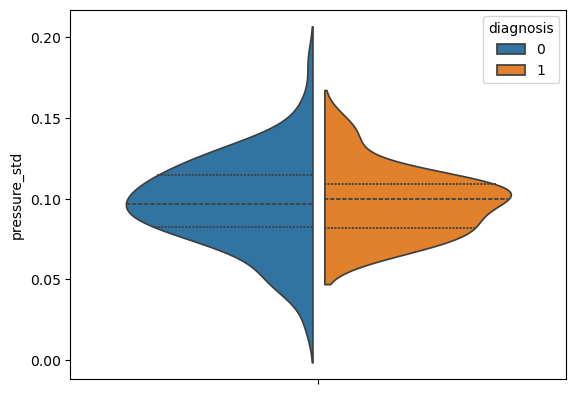

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df_task19_1, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task19_1, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task19_1, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task19_1, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task19_1, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df_task19_1, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [79]:
# Mann-Whitney U test 10_1

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_19_1 = df_hc_task19_1["x_velocity_mean"]
preLBD_xvel_mean_19_1 = df_preLBD_task19_1["x_velocity_mean"]

stat_xvel_mean_19_1, p_xvel_mean_19_1 = mannwhitneyu(hc_xvel_mean_19_1, preLBD_xvel_mean_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_19_1}, p-value={p_xvel_mean_19_1}")
## X - axis velocity std

hc_xvel_std_19_1 = df_hc_task19_1["x_velocity_std"]
preLBD_xvel_std_19_1 = df_preLBD_task19_1["x_velocity_std"]

stat_xvel_std_19_1, p_xvel_std_19_1 = mannwhitneyu(hc_xvel_std_19_1, preLBD_xvel_std_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_19_1}, p-value={p_xvel_std_19_1}")
## Y - axis velocity mean
hc_yvel_mean_19_1 = df_hc_task19_1["y_velocity_mean"]
preLBD_yvel_mean_19_1 = df_preLBD_task19_1["y_velocity_mean"]

stat_yvel_mean_19_1, p_yvel_mean_19_1 = mannwhitneyu(hc_yvel_mean_19_1, preLBD_yvel_mean_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_19_1}, p-value={p_yvel_mean_19_1}")
## Y - axis velocity std
hc_yvel_std_19_1 = df_hc_task19_1["y_velocity_std"]
preLBD_yvel_std_19_1 = df_preLBD_task19_1["y_velocity_std"]

stat_yvel_std_19_1, p_yvel_std_19_1 = mannwhitneyu(hc_yvel_std_19_1, preLBD_yvel_std_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_19_1}, p-value={p_yvel_std_19_1}")
## Pressure mean
hc_pressure_mean_19_1 = df_hc_task19_1["pressure_mean"]
preLBD_pressure_mean_19_1 = df_preLBD_task19_1["pressure_mean"]

stat_pressure_mean_19_1, p_pressure_mean_19_1 = mannwhitneyu(hc_pressure_mean_19_1, preLBD_pressure_mean_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_19_1}, p-value={p_pressure_mean_19_1}")
## Pressure std
hc_pressure_std_19_1 = df_hc_task19_1["y_velocity_std"]
preLBD_pressure_std_19_1 = df_preLBD_task19_1["y_velocity_std"]

stat_pressure_std_19_1, p_pressure_std_19_1 = mannwhitneyu(hc_pressure_std_19_1, preLBD_pressure_std_19_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_19_1}, p-value={p_pressure_std_19_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=1560.0, p-value=0.4058568965127748
Mann-Whitney U Test for X-axis Velocity std: U-statistic=1439.0, p-value=0.15224103013005327
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=1674.0, p-value=0.7906320998287403
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=1558.0, p-value=0.400274264677012
Mann-Whitney U Test for Pressure Mean: U-statistic=1596.0, p-value=0.5140404612471751
Mann-Whitney U Test for Pressure std: U-statistic=1558.0, p-value=0.400274264677012
